## Análisis exploratorio sobre los datos de WIDS 2024

## Competition Overview
The Women in Data Science (WiDS) Datathon 2024 Challenge 1 focuses on **equity in healthcare AI**, specifically addressing demographic parity in medical diagnosis predictions.

## Problem Statement
Develop machine learning models that can predict medical diagnoses while ensuring **equitable performance across different demographic groups**. The challenge emphasizes creating AI systems that work fairly for all patients regardless of their demographic characteristics.

## Dataset Description

### Files Available
- **training.csv** (11.3 MB) - Training dataset with features and target labels
- **test.csv** (5.0 MB) - Test dataset for final predictions 
- **sample_submission.csv** (69.5 KB) - Example submission format

### Key Features
The dataset contains medical and demographic information including:
- **Medical indicators**: Various health metrics and diagnostic measurements
- **Demographic variables**: Age, gender, ethnicity, and other demographic factors
- **Target variable**: Medical diagnosis outcome (binary classification)

## Evaluation Criteria
Models are evaluated on:
1. **Overall predictive accuracy**
2. **Demographic parity**: Ensuring equal performance across demographic groups
3. **Fairness metrics**: Measuring bias and equity in predictions

## Challenge Focus
This competition specifically addresses the critical issue of **algorithmic bias in healthcare AI**, encouraging participants to develop models that are both accurate and equitable across diverse patient populations.

## Data Ethics
Participants must consider:
- Patient privacy and data protection
- Bias mitigation techniques
- Fairness-aware machine learning approaches
- Responsible AI development practices

---
*Source: [Kaggle WIDS Datathon 2024 Challenge 1](https://www.kaggle.com/competitions/widsdatathon2024-challenge1/data)*

In [1]:
## Importacion de librerias esenciales para manipulacion de datos y visualizacion
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
import math





# Importacion de algoritmos de clasificacion
from sklearn.linear_model import LogisticRegression, SGDClassifier 
from sklearn.svm import SVC                                     
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier 
from sklearn.neural_network import MLPClassifier                 
from lightgbm import LGBMClassifier                             
from xgboost import XGBClassifier                                

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.feature_selection import RFECV 
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler 
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc

# Guardado y carga de modelos entrenados
from joblib import dump, load



# Librerias de Scikit-Learn para preprocesamiento y modelado
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler 
from sklearn.decomposition import PCA

# Configuracion para ignorar advertencias de versiones futuras y mantener la salida limpia
warnings.simplefilter(action='ignore', category=FutureWarning)

## Importar datos

In [2]:
## Carga de Datasets
# Cargamos los conjuntos de entrenamiento y prueba.
# Es vital verificar que las rutas sean accesibles en el entorno de ejecucion.
df_training = pd.read_csv('../data/training.csv')
df_test = pd.read_csv('../data/test.csv')

# Guardamos los IDs del test antes de borrar columnas para la submission final
test_ids = df_test['patient_id'].copy()

## Eliminacion de columnas irrelevantes
# Quitamos identificadores unicos y descripciones de texto libre que no aportan valor predictivo directo
# o que podrian causar sobreajuste (overfitting).
df_training.drop(columns=['patient_id','breast_cancer_diagnosis_desc','metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type'], inplace=True)
df_test.drop(columns =['patient_id','breast_cancer_diagnosis_desc','metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type'], inplace=True)

df_training.head()

,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,metastatic_cancer_diagnosis_code,Region,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,NaN,MEDICAID,CA,924,84,F,NaN,C50919,C7989,West,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,White,COMMERCIAL,CA,928,62,F,28.49,C50411,C773,West,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,White,COMMERCIAL,TX,760,43,F,38.09,C50112,C773,South,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,White,COMMERCIAL,CA,926,45,F,NaN,C50212,C773,West,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,C773,West,...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0


In [3]:
# Verificamos dimensiones para asegurar que la carga fue correcta
df_training.shape

(12906, 79)

In [4]:
df_test.shape

(5792, 78)

In [5]:
# Revision general de tipos de datos y memoria
df_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 79 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patient_race                      6521 non-null   object 
 1   payer_type                        11103 non-null  object 
 2   patient_state                     12855 non-null  object 
 3   patient_zip3                      12906 non-null  int64  
 4   patient_age                       12906 non-null  int64  
 5   patient_gender                    12906 non-null  object 
 6   bmi                               3941 non-null   float64
 7   breast_cancer_diagnosis_code      12906 non-null  object 
 8   metastatic_cancer_diagnosis_code  12906 non-null  object 
 9   Region                            12854 non-null  object 
 10  Division                          12854 non-null  object 
 11  population                        12905 non-null  float64
 12  dens

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 78 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patient_race                      2891 non-null   object 
 1   payer_type                        5032 non-null   object 
 2   patient_state                     5771 non-null   object 
 3   patient_zip3                      5792 non-null   int64  
 4   patient_age                       5792 non-null   int64  
 5   patient_gender                    5792 non-null   object 
 6   bmi                               1777 non-null   float64
 7   breast_cancer_diagnosis_code      5792 non-null   object 
 8   metastatic_cancer_diagnosis_code  5792 non-null   object 
 9   Region                            5771 non-null   object 
 10  Division                          5771 non-null   object 
 11  population                        5792 non-null   float64
 12  densit

In [7]:
# Separacion de variables segun su tipo para facilitar el analisis exploratorio (EDA)
categorical_cols = df_training.select_dtypes(include=['object']).columns
numerical_cols = df_training.select_dtypes(include=['int64', 'float64']).columns

Compara columnas entre ambos archivos. La diferencia fundamental es que `df_training` contiene la variable objetivo `DiagPeriodL90D`, la cual debemos predecir en `test`.

In [8]:
# Analisis estadistico descriptivo de las variables numericas
# Usamos background_gradient para visualizar rapidamente valores altos y bajos
df_training.describe().T.style.background_gradient(cmap='Oranges').format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
patient_zip3,12906.00,573.75,275.45,101.00,331.00,554.00,846.00,999.00
patient_age,12906.00,59.18,13.34,18.00,50.00,59.00,67.00,91.00
bmi,3941.00,28.98,5.70,14.00,24.66,28.19,32.92,85.00
population,12905.00,20744.44,13886.90,635.55,9463.90,19154.19,30021.28,71374.13
density,12905.00,1581.95,2966.31,0.92,171.86,700.34,1666.52,21172.00
age_median,12905.00,40.50,4.04,20.60,37.13,40.64,42.93,54.57
age_under_10,12905.00,11.12,1.51,0.00,10.16,11.04,12.19,17.68
age_10_to_19,12905.00,12.95,1.92,6.31,11.74,12.92,14.02,35.30
age_20s,12905.00,13.29,3.35,5.92,11.01,12.54,14.97,62.10
age_30s,12905.00,12.86,2.32,1.50,11.29,12.44,14.03,25.47


In [9]:
print("Datos de train",df_training.shape)
print("Datos de test",df_test.shape)

Datos de train (12906, 79)
Datos de test (5792, 78)


## Tratamiento de datos nulos

Analisis de calidad de datos: Identificamos que `bmi`, `patient_race` y `payer_type` contienen el mayor porcentaje de valores ausentes.

In [10]:
# Calculo del porcentaje de valores nulos por columna en Training
null_percentage = (round(df_training.isnull().mean()*100,2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
bmi,69.46
patient_race,49.47
payer_type,13.97
patient_state,0.40
Division,0.40
Region,0.40
PM25,0.22
N02,0.22
Ozone,0.22
income_household_six_figure,0.03


In [11]:
# Calculo del porcentaje de valores nulos por columna en Test
null_percentage = (round(df_test.isnull().mean()*100,2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
bmi,69.32
patient_race,50.09
payer_type,13.12
patient_state,0.36
Region,0.36
Division,0.36
N02,0.24
Ozone,0.24
PM25,0.24
income_household_150_over,0.02


##### Variable: BMI (Índice de Masa Corporal)

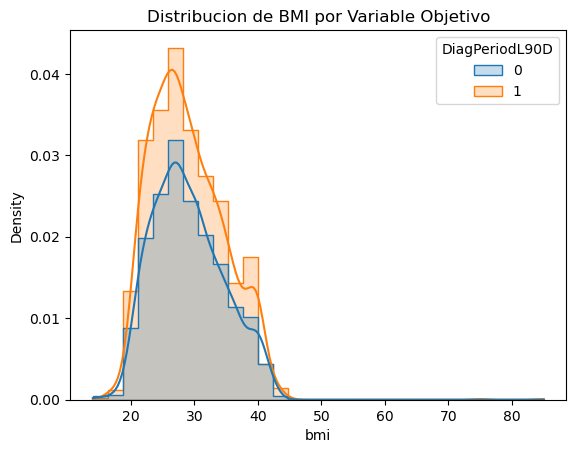

In [12]:
# Visualizacion de la distribucion del BMI respecto a la variable objetivo
sns.histplot(data=df_training, x='bmi', hue='DiagPeriodL90D', bins=30, kde=True, element='step', stat='density')
plt.title('Distribucion de BMI por Variable Objetivo')
plt.show()

In [13]:
## Ingenieria de caracteristicas: Categorizacion del BMI
# Convertimos una variable numerica continua en categorias clinicas estandar.
df_training['bmi_category'] = pd.cut(df_training['bmi'], bins=[0, 18.5, 24.9, 29.9, 34.9,39.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obesity I', 'Obesity II','Extreme']).astype(object)
df_test['bmi_category'] = pd.cut(df_test['bmi'], bins=[0, 18.5, 24.9, 29.9, 34.9,39.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obesity I', 'Obesity II','Extreme']).astype(object)

# Imputacion de nulos en la nueva categoria como 'Unknown'
df_training['bmi_category'] = df_training['bmi_category'].fillna('Unknown')
df_test['bmi_category'] = df_test['bmi_category'].fillna('Unknown')

In [14]:
# Analisis de la relacion entre la categoria de BMI y la variable objetivo
display(pd.crosstab(df_training['bmi_category'], df_training['DiagPeriodL90D'], normalize='index', margins=True))

DiagPeriodL90D,0,1
bmi_category,,
Extreme,0.410256,0.589744
Normal,0.399600,0.600400
Obesity I,0.430752,0.569248
Obesity II,0.406316,0.593684
Overweight,0.412472,0.587528
Underweight,0.409091,0.590909
Unknown,0.359175,0.640825
All,0.375484,0.624516


In [15]:
# Verificacion del balance de clases
print("Proporcion Variable Objetivo:")
print(df_training['DiagPeriodL90D'].value_counts(normalize=True))
print("\nHay una desproporcion en los datos de nuestra variable objetivo.")

Proporcion Variable Objetivo:
DiagPeriodL90D
1    0.624516
0    0.375484
Name: proportion, dtype: float64

Hay una desproporcion en los datos de nuestra variable objetivo.


#### Tratamiento "patient_race" y "payer_type"

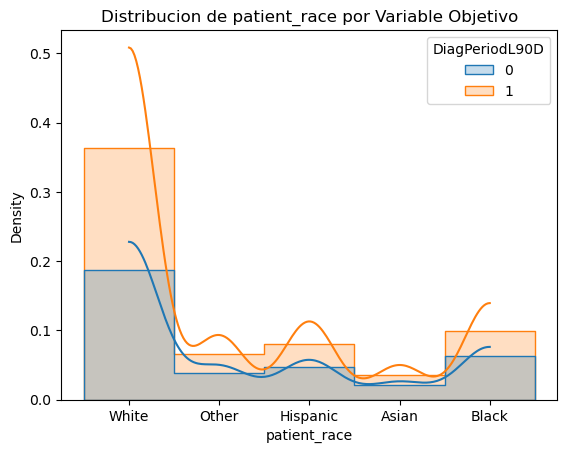

In [16]:
# Visualizacion de la raza del paciente
sns.histplot(data=df_training, x='patient_race', hue='DiagPeriodL90D', bins=30, kde=True, element='step', stat='density')
plt.title('Distribucion de patient_race por Variable Objetivo')
plt.show()

In [17]:
# Imputacion de variables categoricas clave
# Asumimos que la falta de datos es informativa, creando una categoria explicita.
df_training['patient_race'] = df_training['patient_race'].fillna('Unknown')
df_test['patient_race'] = df_test['patient_race'].fillna('Unknown')

df_training['payer_type'] = df_training['payer_type'].fillna('No insurance')
df_test['payer_type'] = df_test['payer_type'].fillna('No insurance')

## Tratamiento de Nulos Restantes (Train y Test)

Para el resto de columnas con bajo porcentaje de nulos, utilizaremos estrategias de imputación estadística simple.

In [18]:
null_percentage = (round(df_training.isnull().mean()*100, 2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
bmi,69.46
patient_state,0.40
Division,0.40
Region,0.40
PM25,0.22
N02,0.22
Ozone,0.22
income_household_20_to_25,0.03
home_ownership,0.03
family_dual_income,0.03


#### Imputación con Media y Moda (SimpleImputer)

In [19]:
# Estrategia de imputacion para valores restantes
# Identificar columnas numericas y categoricas que aun tienen nulos
numeric_cols_with_nulls = df_training.select_dtypes(include=np.number).columns[df_training.select_dtypes(include=np.number).isnull().any()].tolist()
categorical_cols_with_nulls = df_training.select_dtypes(include='object').columns[df_training.select_dtypes(include='object').isnull().any()].tolist()

print(f"Columnas numericas a imputar (con media): {numeric_cols_with_nulls}")
print(f"Columnas categoricas a imputar (con moda): {categorical_cols_with_nulls}")

# Imputacion Numerica (Media)
if numeric_cols_with_nulls: 
    imputer_mean = SimpleImputer(strategy='mean')
    # Ajustamos (fit) solo en train para evitar data leakage
    imputer_mean.fit(df_training[numeric_cols_with_nulls])
    
    # Transformamos ambos sets
    df_training[numeric_cols_with_nulls] = imputer_mean.transform(df_training[numeric_cols_with_nulls])
    df_test[numeric_cols_with_nulls] = imputer_mean.transform(df_test[numeric_cols_with_nulls])

# Imputacion Categorica (Moda / Mas Frecuente)
if categorical_cols_with_nulls: 
    imputer_mode = SimpleImputer(strategy='most_frequent')
    imputer_mode.fit(df_training[categorical_cols_with_nulls])
    
    df_training[categorical_cols_with_nulls] = imputer_mode.transform(df_training[categorical_cols_with_nulls])
    df_test[categorical_cols_with_nulls] = imputer_mode.transform(df_test[categorical_cols_with_nulls])

print(f"Valores nulos restantes en train: {df_training.isnull().sum().sum()}")
print(f"Valores nulos restantes en test: {df_test.isnull().sum().sum()}")

Columnas numericas a imputar (con media): ['bmi', 'population', 'density', 'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s', 'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male', 'female', 'married', 'divorced', 'never_married', 'widowed', 'family_size', 'family_dual_income', 'income_household_median', 'income_household_under_5', 'income_household_5_to_10', 'income_household_10_to_15', 'income_household_15_to_20', 'income_household_20_to_25', 'income_household_25_to_35', 'income_household_35_to_50', 'income_household_50_to_75', 'income_household_75_to_100', 'income_household_100_to_150', 'income_household_150_over', 'income_household_six_figure', 'income_individual_median', 'home_ownership', 'housing_units', 'home_value', 'rent_median', 'rent_burden', 'education_less_highschool', 'education_highschool', 'education_some_college', 'education_bachelors', 'education_graduate', 'education_college_or_above', 'education_stem_degree', 'labor_force_participation',

In [20]:
# Verificacion final de limpieza en Test
null_percentage = (round(df_test.isnull().mean()*100,2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
patient_race,0.0
payer_type,0.0
patient_state,0.0
patient_zip3,0.0
patient_age,0.0
patient_gender,0.0
bmi,0.0
breast_cancer_diagnosis_code,0.0
metastatic_cancer_diagnosis_code,0.0
Region,0.0


In [21]:
# Verificacion final de limpieza en Train
null_percentage = (round(df_training.isnull().mean()*100,2)).to_frame(name='Porcentaje de valores nulos').sort_values(by='Porcentaje de valores nulos', ascending=False)
display(null_percentage.head(20))

,Porcentaje de valores nulos
patient_race,0.0
payer_type,0.0
patient_state,0.0
patient_zip3,0.0
patient_age,0.0
patient_gender,0.0
bmi,0.0
breast_cancer_diagnosis_code,0.0
metastatic_cancer_diagnosis_code,0.0
Region,0.0


## Identificar y eliminar los duplicados

In [22]:
print(f"Duplicados en Train: {df_training.duplicated().sum()}")
print(f"Duplicados en Test: {df_test.duplicated().sum()}")

# Eliminamos filas identicas para evitar sesgos en la evaluacion
df_training = df_training.drop_duplicates()
df_test = df_test.drop_duplicates()

# Reseteamos indices para mantener la integridad del dataframe
df_training = df_training.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

Duplicados en Train: 36
Duplicados en Test: 7


In [23]:
print(f"Duplicados en Train: {df_training.duplicated().sum()}")
print(f"Duplicados en Test: {df_test.duplicated().sum()}")

Duplicados en Train: 0
Duplicados en Test: 0


## Analisis Exploratorio (EDA) - General

In [24]:
# Generacion de un reporte descriptivo personalizado
# Combina tipos de datos, conteos unicos y porcentajes de nulos
desc = pd.DataFrame(index = list(df_training.columns))
desc['type'] = df_training.dtypes
desc['count'] = df_training.count()
desc['nunique'] = df_training.nunique()
desc['%unique'] = desc['nunique'] /len(df_training) * 100
desc['null'] = df_training.isnull().sum()
desc['%null'] = desc['null'] / len(df_training) * 100
desc = pd.concat([desc,df_training.describe().T.drop('count',axis=1)],axis=1)

display(desc.sort_values(by=['type','null']).style.background_gradient(axis=0))

,type,count,nunique,%unique,null,%null,mean,std,min,25%,50%,75%,max
patient_zip3,int64,12870,739,5.742036,0,0.000000,573.683683,275.492242,101.000000,331.000000,554.000000,847.000000,999.000000
patient_age,int64,12870,67,0.520591,0,0.000000,59.172960,13.331272,18.000000,50.000000,59.000000,67.000000,91.000000
DiagPeriodL90D,int64,12870,2,0.015540,0,0.000000,0.624476,0.484277,0.000000,0.000000,1.000000,1.000000,1.000000
bmi,float64,12870,1343,10.435120,0,0.000000,28.984539,3.152207,14.000000,28.984539,28.984539,28.984539,85.000000
population,float64,12870,739,5.742036,0,0.000000,20742.510548,13891.287168,635.545455,9463.896552,19154.190480,30021.278690,71374.131580
density,float64,12870,739,5.742036,0,0.000000,1581.602968,2966.242368,0.916667,170.550000,700.337500,1666.515385,21172.000000
age_median,float64,12870,729,5.664336,0,0.000000,40.505196,4.038661,20.600000,37.129825,40.639344,42.934783,54.570000
age_under_10,float64,12870,719,5.586636,0,0.000000,11.122328,1.513215,0.000000,10.160000,11.039216,12.190000,17.675000
age_10_to_19,float64,12870,726,5.641026,0,0.000000,12.945587,1.924708,6.314286,11.741176,12.923944,14.019767,35.300000
age_20s,float64,12870,725,5.633256,0,0.000000,13.289247,3.355728,5.925000,11.013415,12.538095,14.971053,62.100000


In [25]:
# Visualizacion masiva de distribuciones numericas (Kernel Density Estimation)
num_cols = df_training.select_dtypes('number').columns.tolist()
target = 'DiagPeriodL90D'
if target in num_cols:
    num_cols.remove(target)

fig, ax = plt.subplots(math.ceil(len(num_cols)/6), 6, figsize=(25,25), dpi=300)
ax = ax.flatten()

for i, col in enumerate(num_cols):
  sns.kdeplot(df_training[col],ax=ax[i],color='b', fill=True)
  ax[i].set_title(f'{col}')
  ax[i].set_xlabel(None) 

# Ocultar ejes sobrantes
for j in range(len(num_cols),len(ax)):
  ax[j].axis('off')

fig.suptitle('Distribution of Numeric Features (Train)', fontsize = 24, fontweight = 'bold')
plt.tight_layout(h_pad=0.1, w_pad=0.5, rect=[0, 0.03, 1, 0.97])
plt.show()

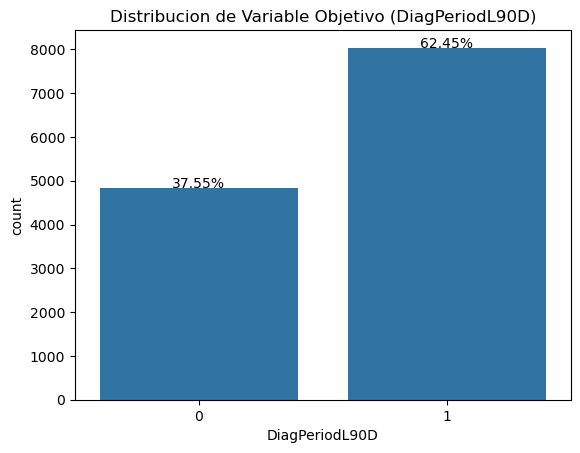

In [26]:
# Distribucion de la Variable Objetivo (Balance de Clases)
ax = sns.countplot(x=df_training['DiagPeriodL90D'])
total = len(df_training['DiagPeriodL90D'])
for p in ax.patches:
  height = p.get_height()
  ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
          '{:.2%}'.format(height / total),
          ha="center")
plt.title('Distribucion de Variable Objetivo (DiagPeriodL90D)')
plt.show()

C:\Users\alda09\AppData\Local\Temp\ipykernel_1468\4088850270.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')
C:\Users\alda09\AppData\Local\Temp\ipykernel_1468\4088850270.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')
C:\Users\alda09\AppData\Local\Temp\ipykernel_1468\4088850270.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')
C:\Users\alda09\AppData\Local\Temp\ipykernel_1468\4088850270.py:12: UserWarning: set_ticklabels() should only be used with a fixed number o

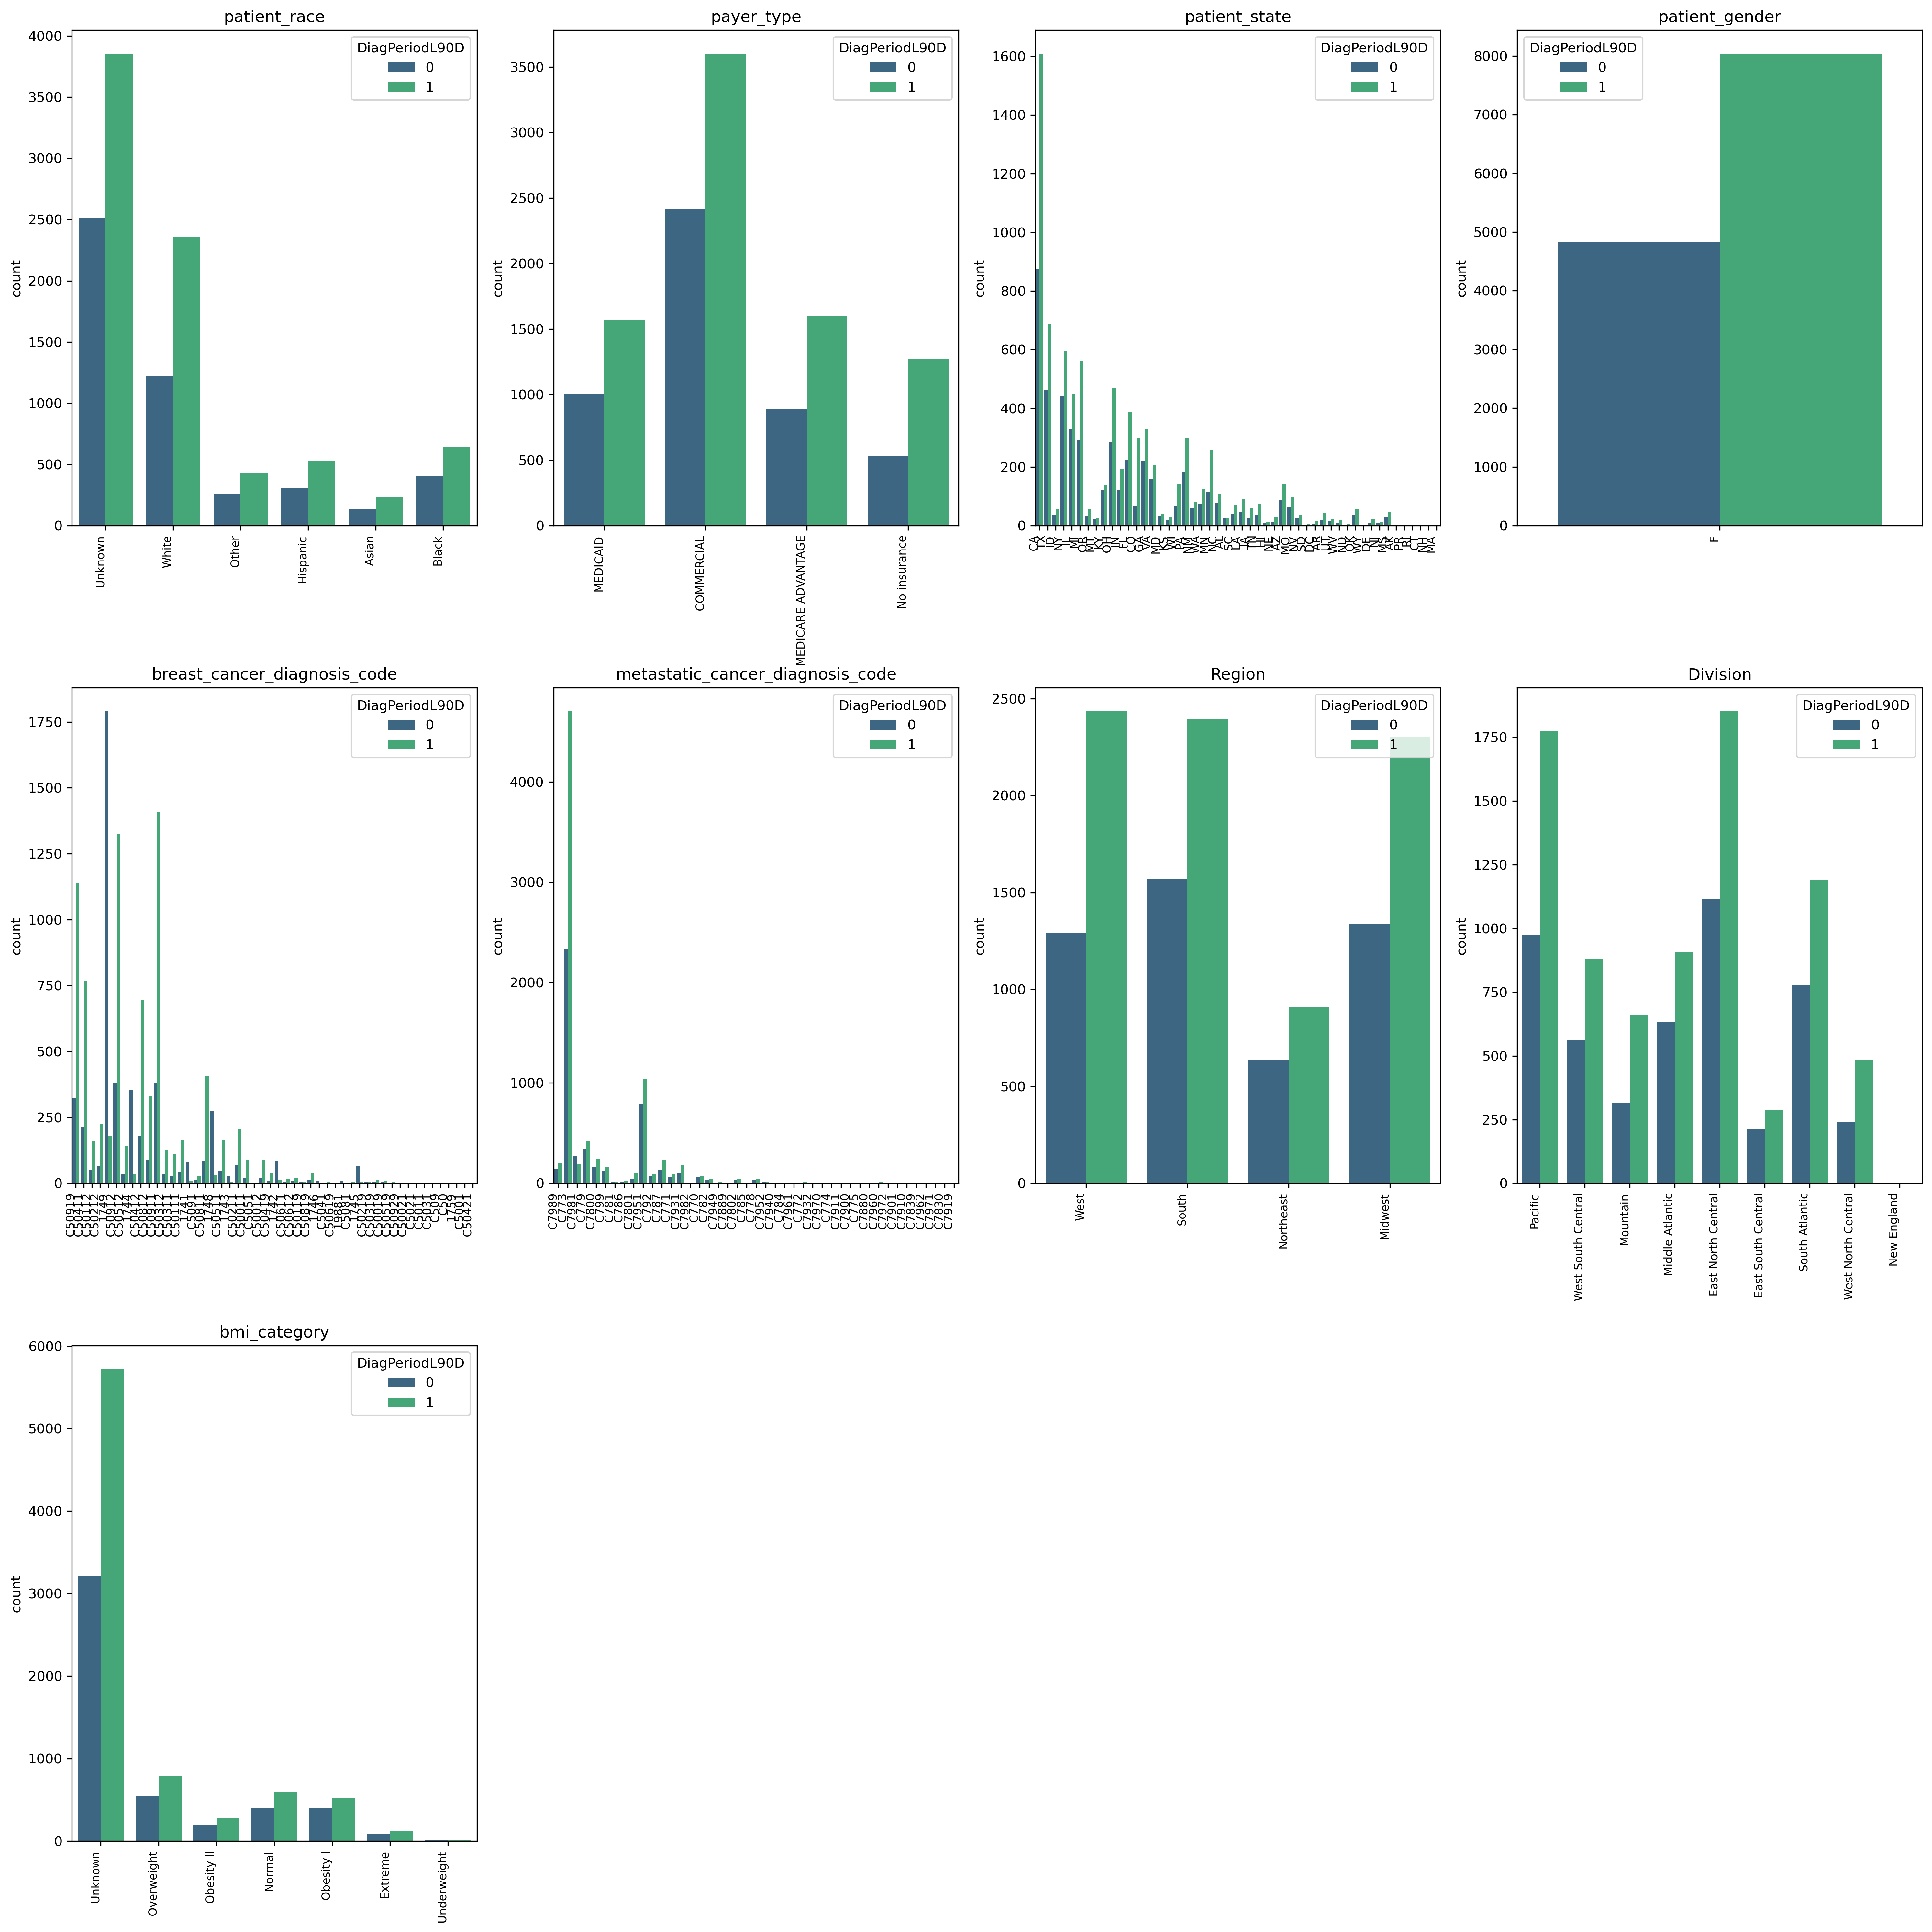

In [27]:
# Distribucion de Variables Categoricas vs Target
cat_cols = df_training.select_dtypes('object').columns.tolist()

fig, ax = plt.subplots(math.ceil(len(cat_cols)/4), 4, figsize=(20,20), dpi=300)
ax = ax.flatten()
plt.subplots_adjust(wspace=0.3, hspace=0.5)

for i, col in enumerate(cat_cols):
  sns.countplot(x=df_training[col],hue=df_training[target],ax=ax[i], palette='viridis')
  ax[i].set_title(f'{col}')
  ax[i].set_xlabel(None)
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90, ha='right',fontsize='small')

for j in range(len(cat_cols),len(ax)):
  ax[j].axis('off')

plt.tight_layout(h_pad=0.1)
plt.show()

## Analisis de Equidad: Tasa de Diagnóstico vs. Grupos Demograficos


In [28]:
def plot_rate_by_group(df, column_name):
    """
    Calcula y grafica la tasa de diagnostico positivo para cada categoria.
    Ayuda a visualizar disparidades entre grupos.
    """
    # Calcular la proporcion (tasa de diagnostico)
    proportions = pd.crosstab(df[column_name], df['DiagPeriodL90D'], normalize='index')
    
    # Ordenar por la tasa de positivos
    proportions = proportions.sort_values(by=1, ascending=False)
    
    print(f"--- Analisis de Tasa de Diagnostico para: {column_name} ---")
    # applymap es util para formatear la salida como porcentaje
    print(proportions.applymap(lambda x: f"{x:.2%}"))
    print("\n")
    
    # Graficar
    ax = proportions.plot(kind='bar', 
                          stacked=True, 
                          figsize=(12, 6), 
                          colormap='viridis',
                          title=f'Tasa de Diagnostico Positivo (1) por {column_name}')
    
    ax.legend(title='DiagPeriodL90D', labels=['No (0)', 'Si (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlabel(column_name)
    ax.set_ylabel('Proporcion')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
    
    # Etiquetas de porcentaje para la clase positiva
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_x(), p.get_y()
        
        if y > 0.5 and height > 0.01: 
             ax.annotate(f'{height:.1%}', (x + width / 2., y + height / 2.), 
                         ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

--- Analisis de Tasa de Diagnostico para: patient_race ---
DiagPeriodL90D       0       1
patient_race                  
White           34.13%  65.87%
Hispanic        36.76%  63.24%
Asian           36.99%  63.01%
Other           37.34%  62.66%
Black           38.69%  61.31%
Unknown         39.44%  60.56%




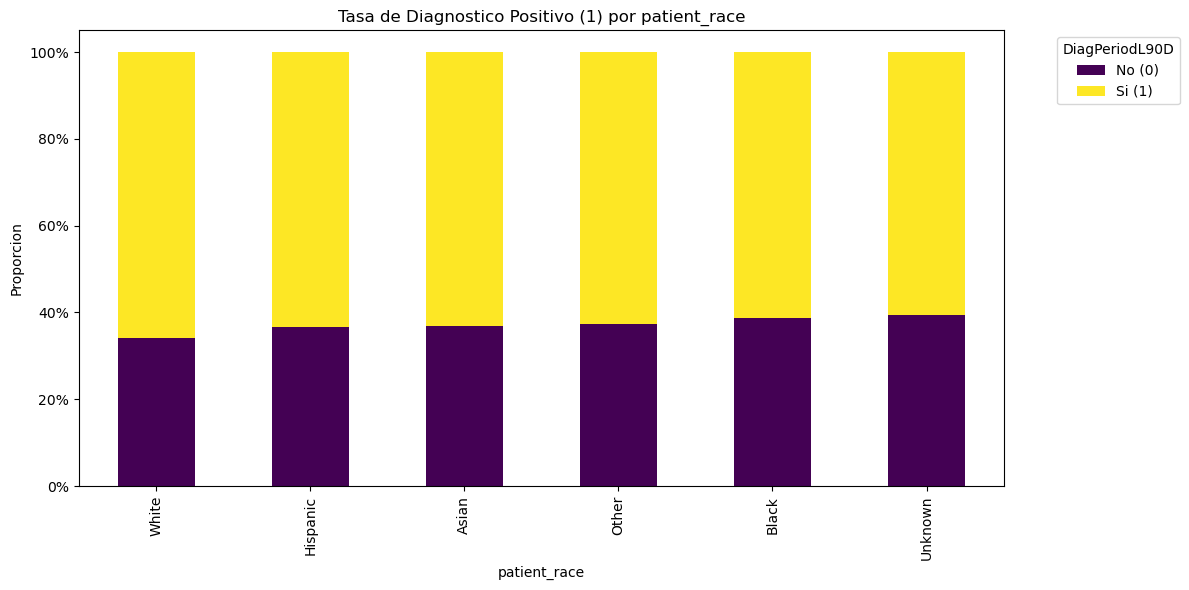

In [29]:
# Analisis por Raza del Paciente (Variable sensible para equidad)
plot_rate_by_group(df_training, 'patient_race')

--- Analisis de Tasa de Diagnostico para: payer_type ---
DiagPeriodL90D           0       1
payer_type                        
No insurance        29.38%  70.62%
MEDICARE ADVANTAGE  35.78%  64.22%
MEDICAID            38.97%  61.03%
COMMERCIAL          40.12%  59.88%




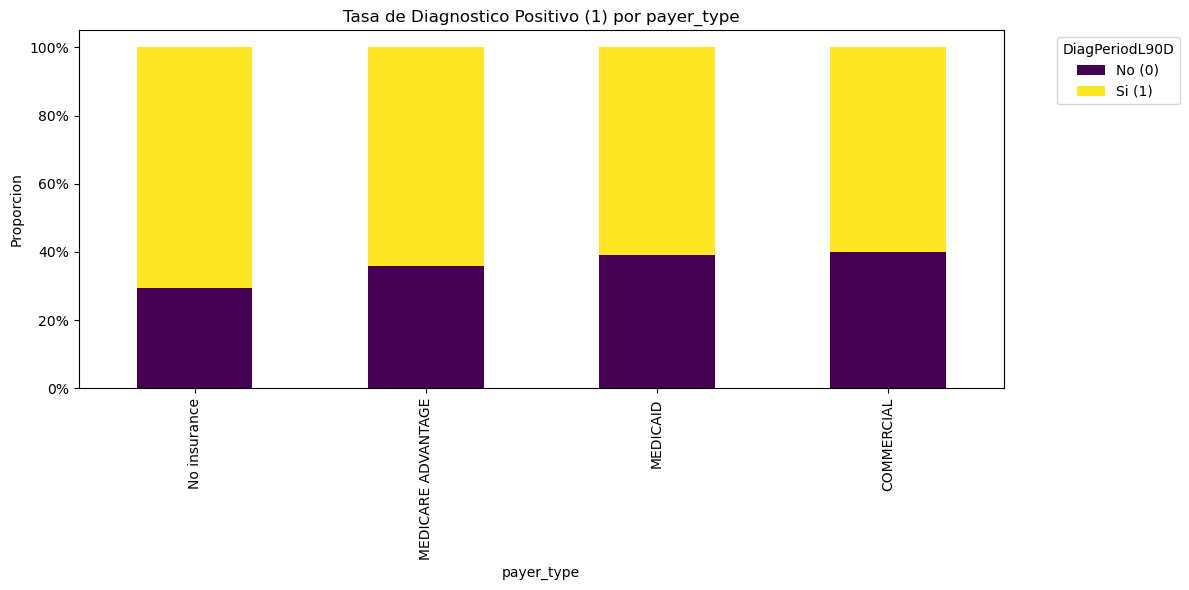

In [30]:
# Analisis por Tipo de Seguro
plot_rate_by_group(df_training, 'payer_type')

--- Analisis de Tasa de Diagnostico para: bmi_category ---
DiagPeriodL90D       0       1
bmi_category                  
Unknown         35.92%  64.08%
Normal          39.96%  60.04%
Obesity II      40.63%  59.37%
Underweight     40.91%  59.09%
Extreme         41.03%  58.97%
Overweight      41.25%  58.75%
Obesity I       43.08%  56.92%




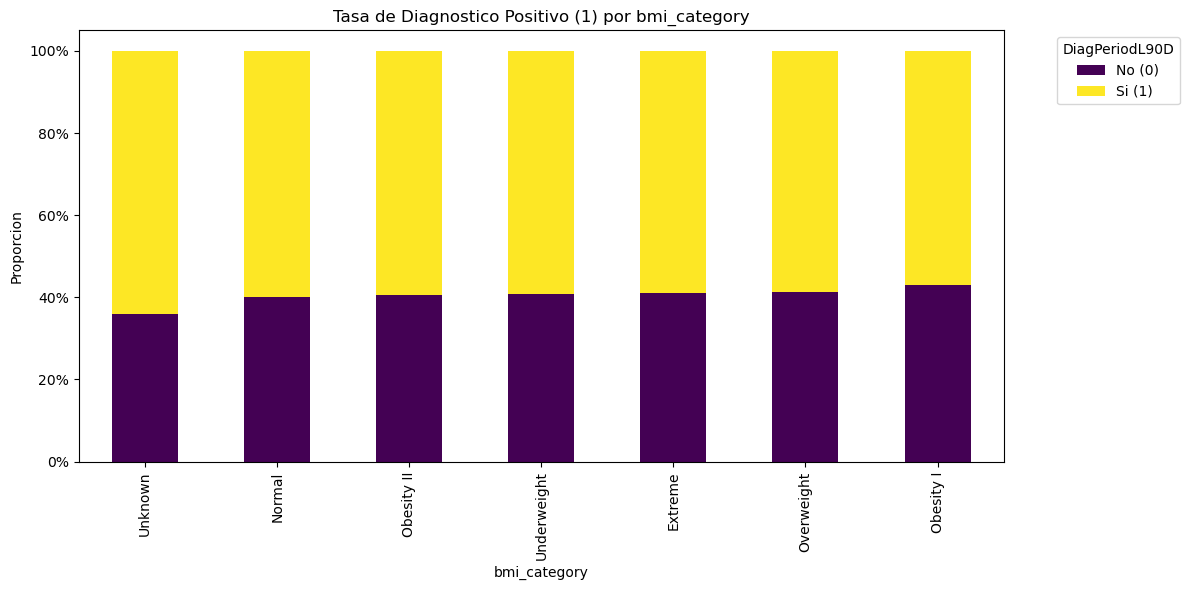

In [31]:
# Analisis por Categoria de BMI
plot_rate_by_group(df_training, 'bmi_category')

--- Analisis de Tasa de Diagnostico para: Region ---
DiagPeriodL90D       0       1
Region                        
West            34.66%  65.34%
Midwest         36.79%  63.21%
South           39.61%  60.39%
Northeast       41.06%  58.94%




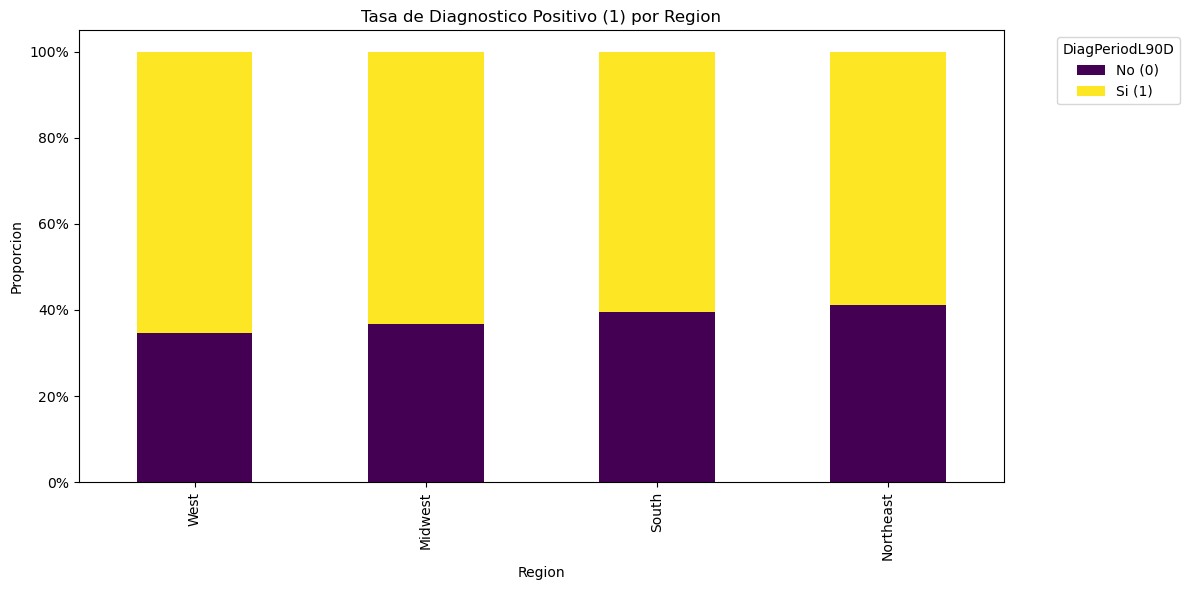

In [32]:
# Analisis Geografico ("region")
plot_rate_by_group(df_training, 'Region')

### Análisis de Distribución Numérica por Variable Objetivo

Analizamos si las distribuciones de variables numéricas clave difieren estadísticamente entre los diagnósticos positivos y negativos.

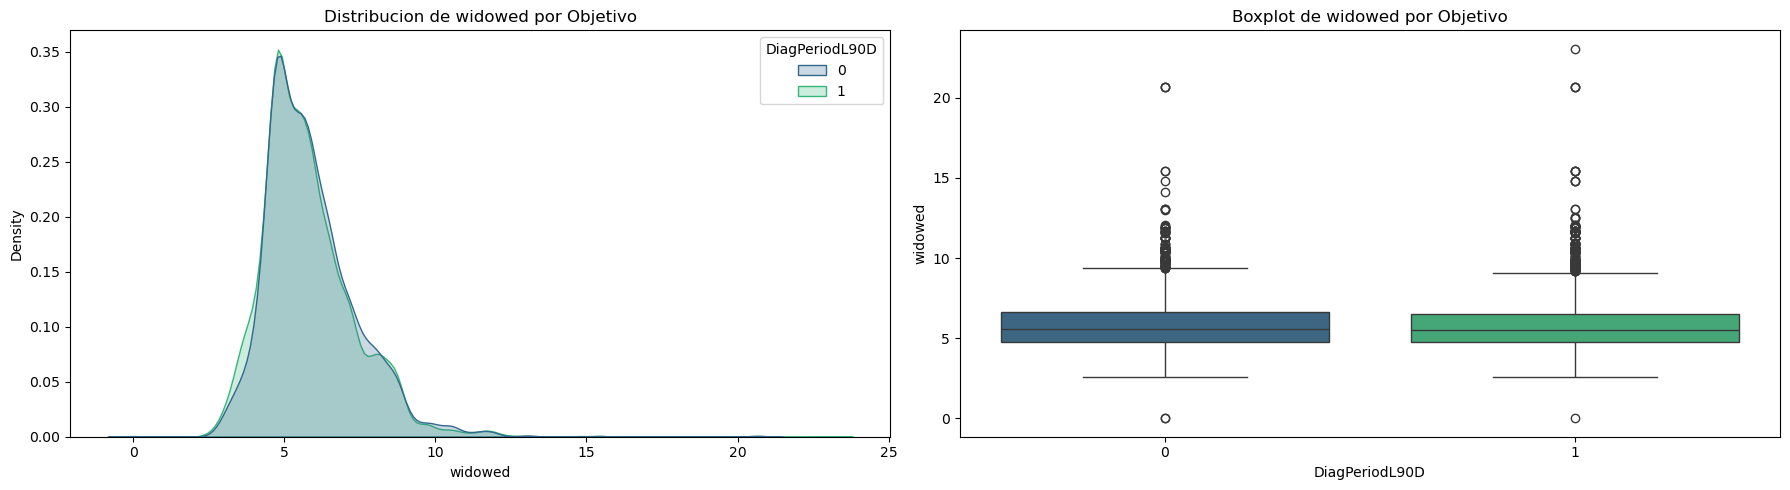

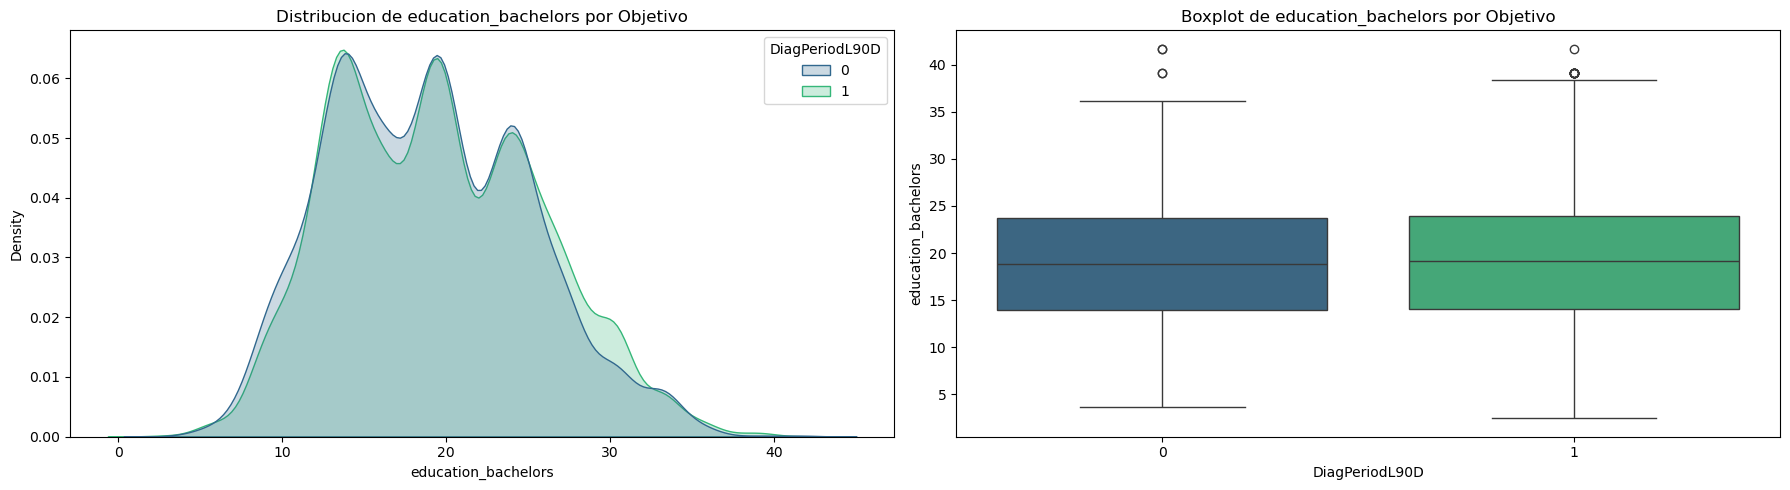

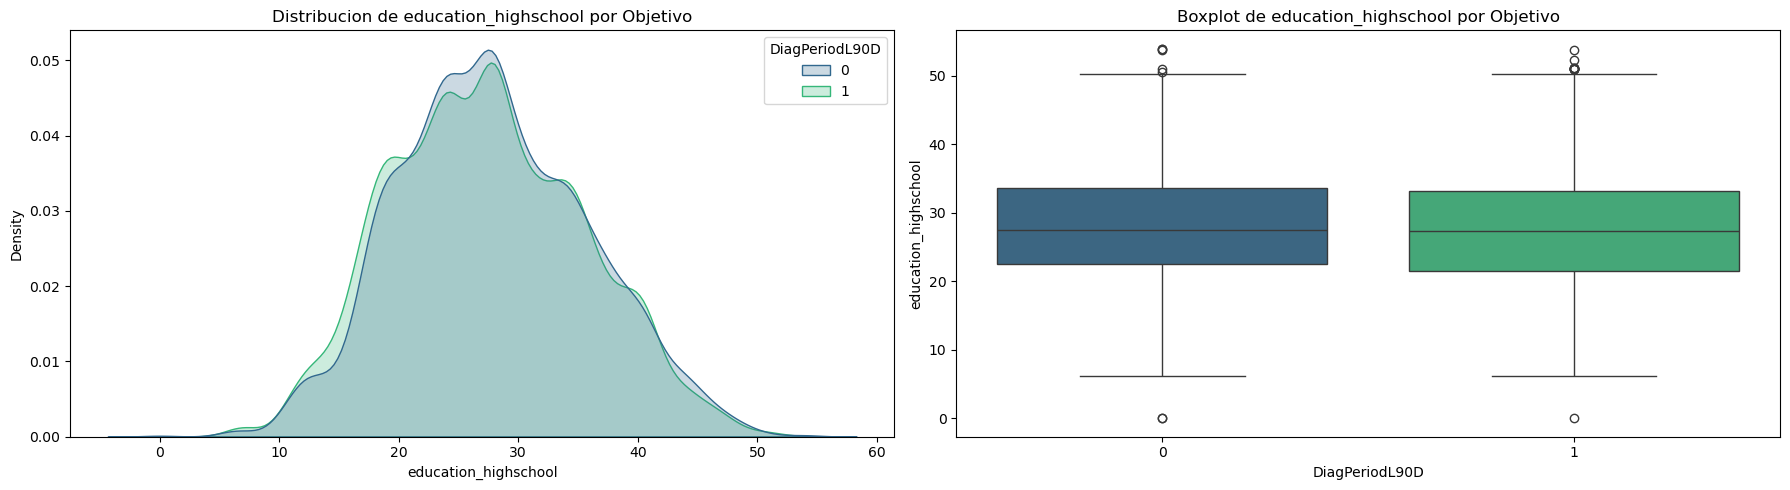

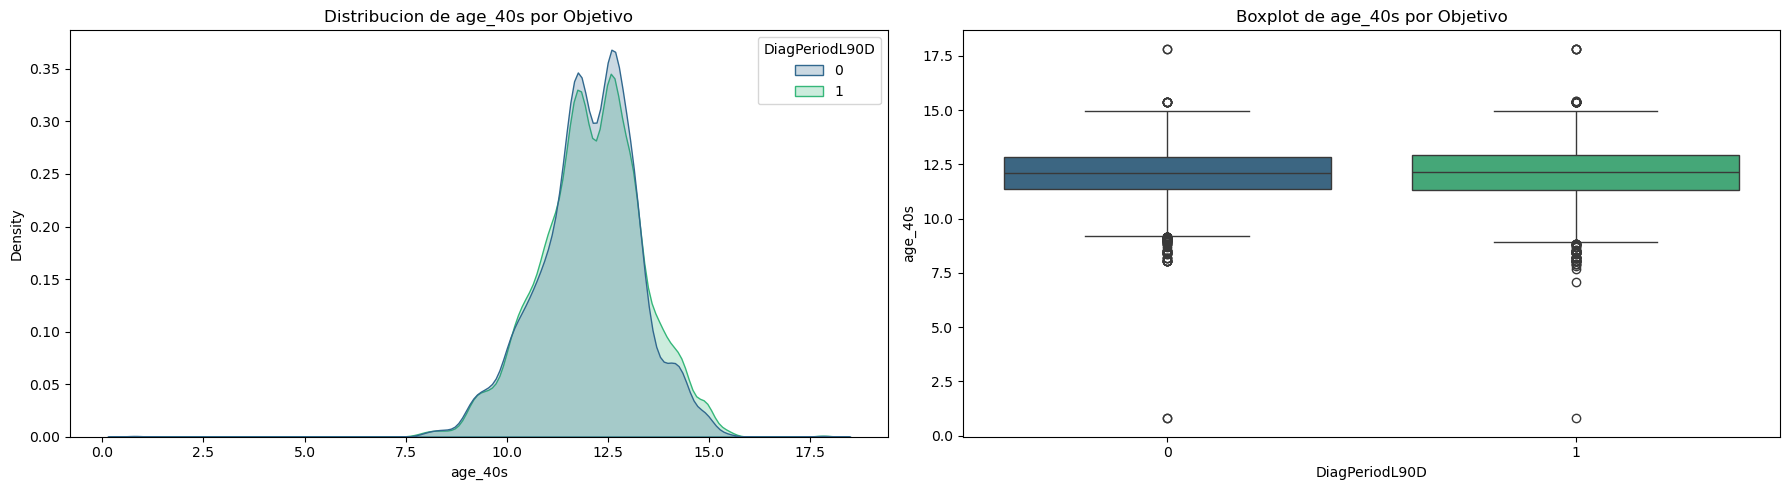

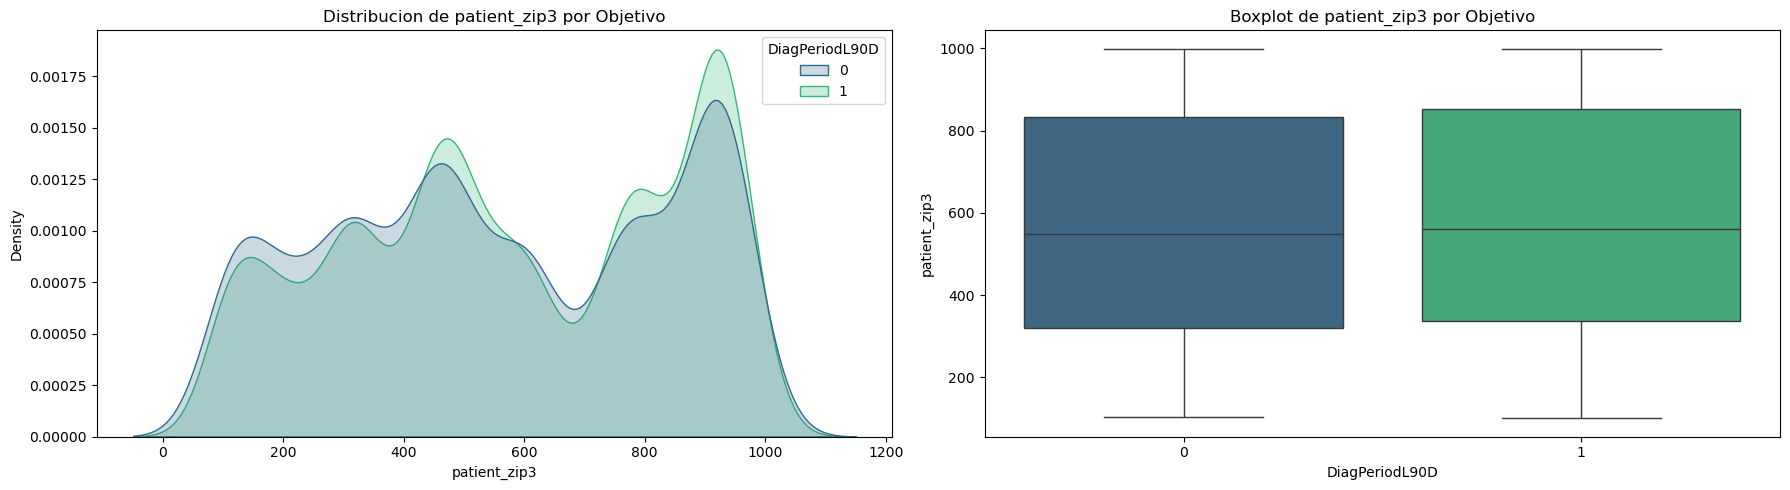

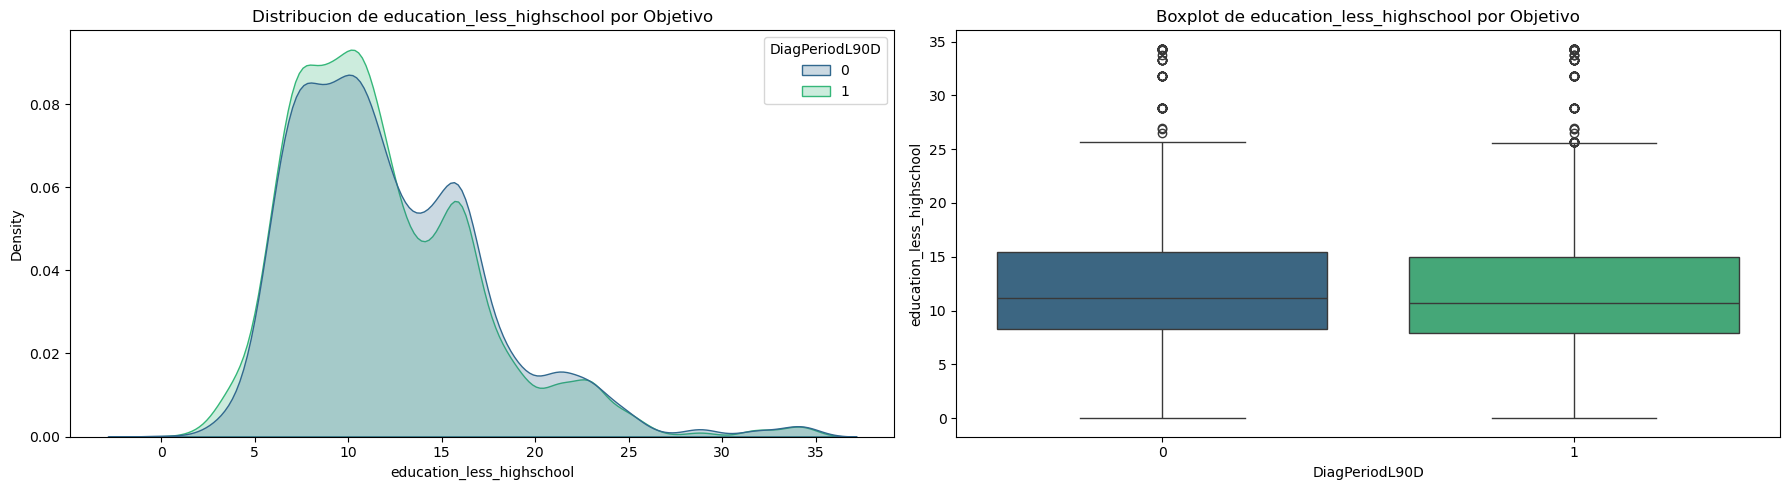

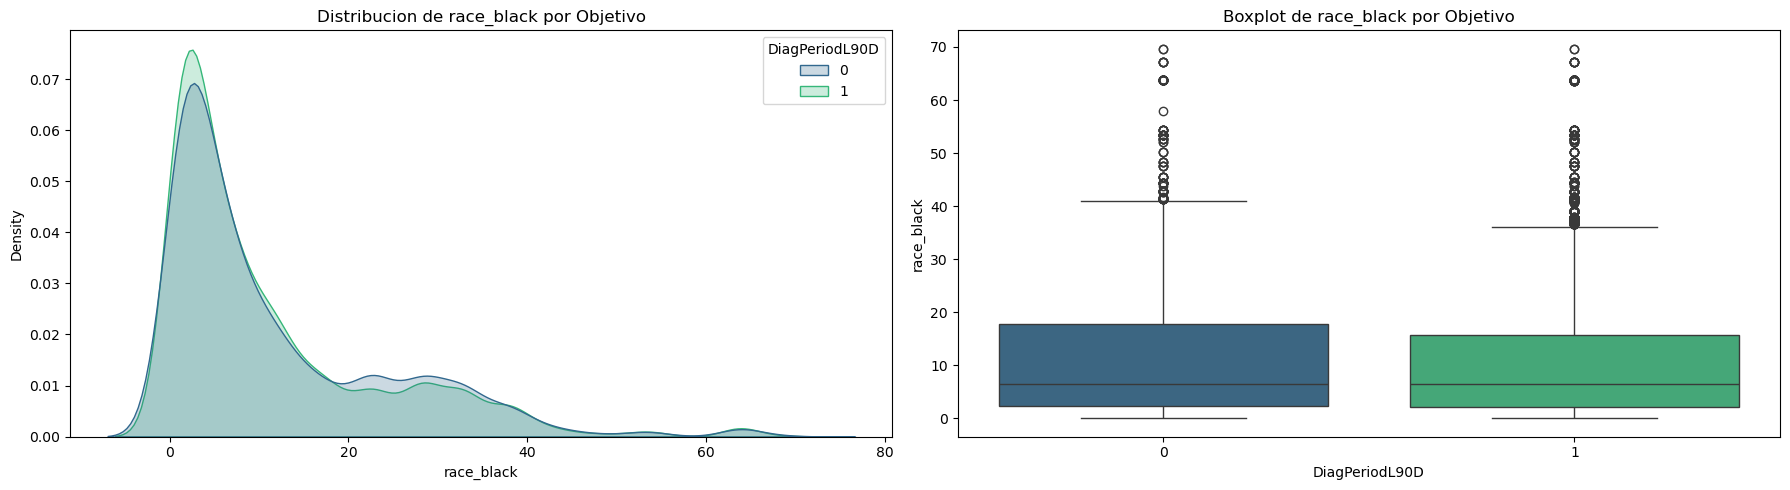

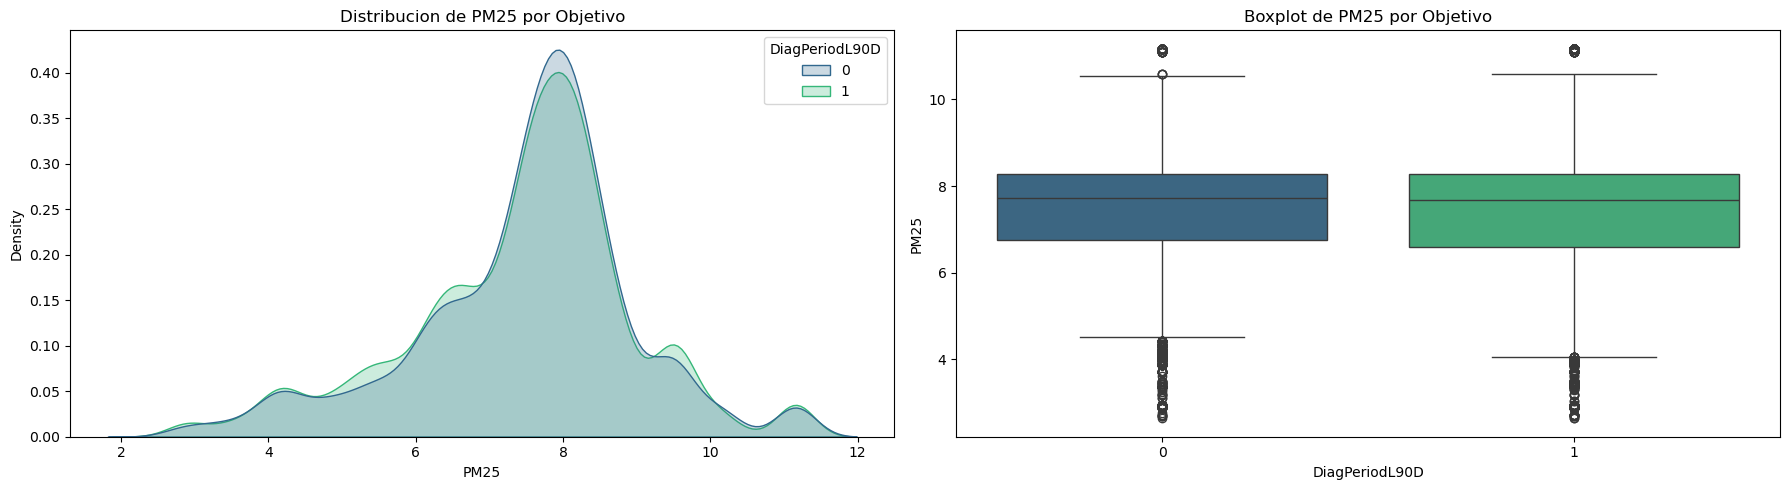

In [33]:
# Variables seleccionadas para inspeccion profunda
variables_a_analizar = [
    'widowed',
    'education_bachelors',
    'education_highschool',
    'age_40s',
    'patient_zip3',
    'education_less_highschool',
    'race_black',
    'PM25'
]
for col in variables_a_analizar:
    plt.figure(figsize=(18, 5))
    
    # Grafico de densidad comparativo
    plt.subplot(1, 2, 1)
    sns.kdeplot(data=df_training, x=col, hue='DiagPeriodL90D', 
                fill=True, common_norm=False, palette='viridis')
    plt.title(f'Distribucion de {col} por Objetivo')
    
    # Boxplot para ver medianas y cuartiles
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_training, x='DiagPeriodL90D', y=col, palette='viridis')
    plt.title(f'Boxplot de {col} por Objetivo')
    
    plt.tight_layout()
    plt.show()

### Ver outliers

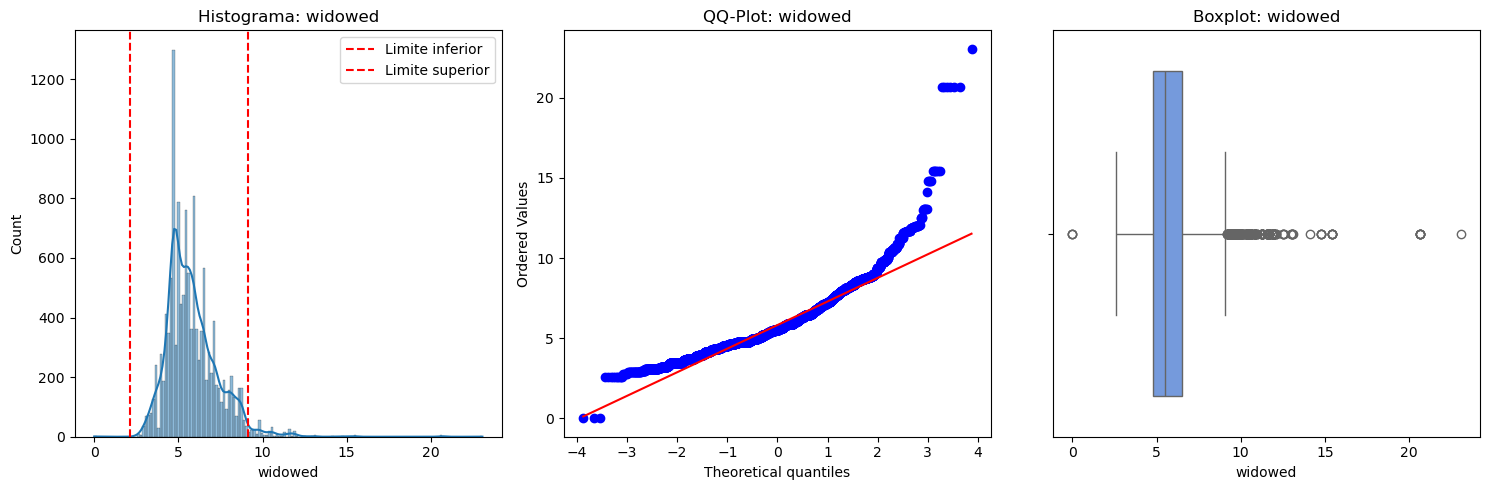

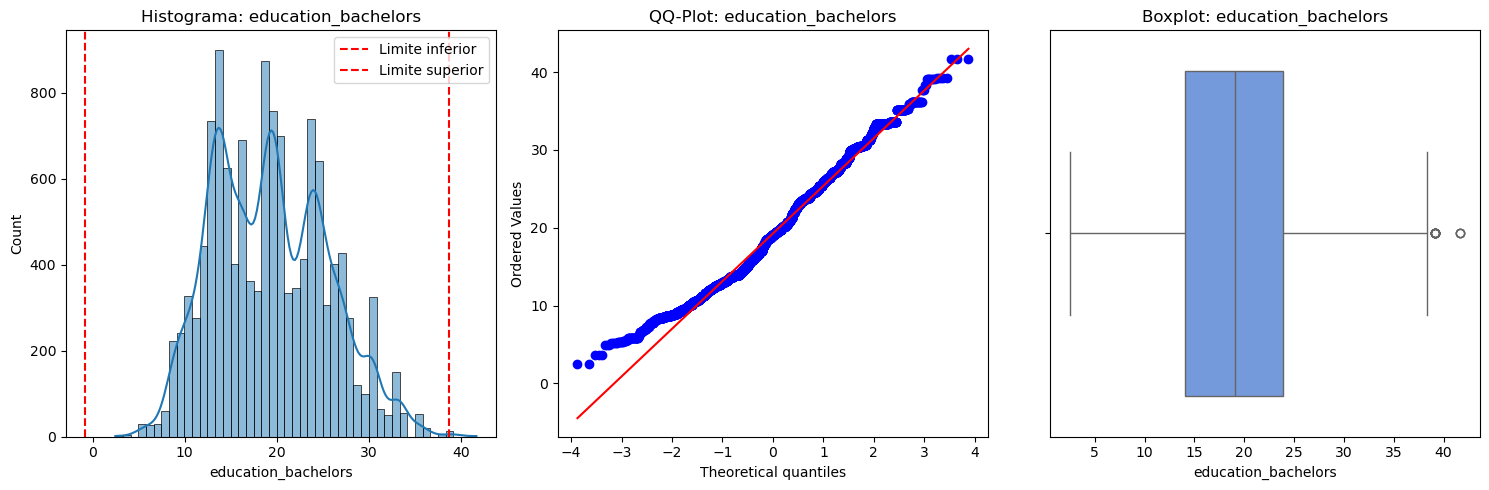

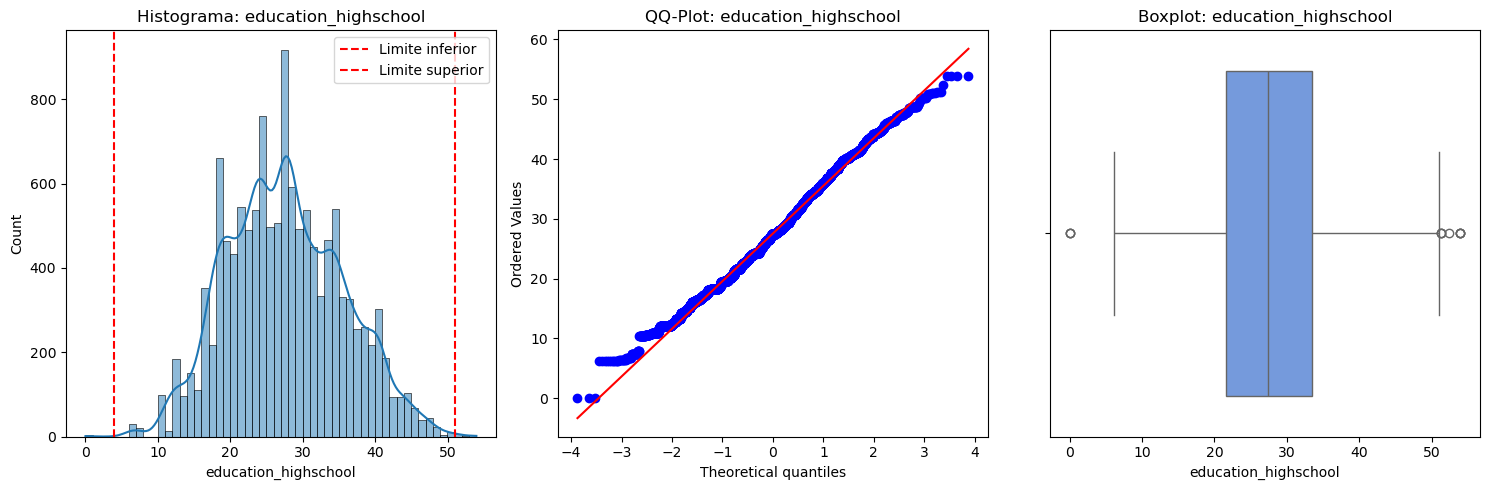

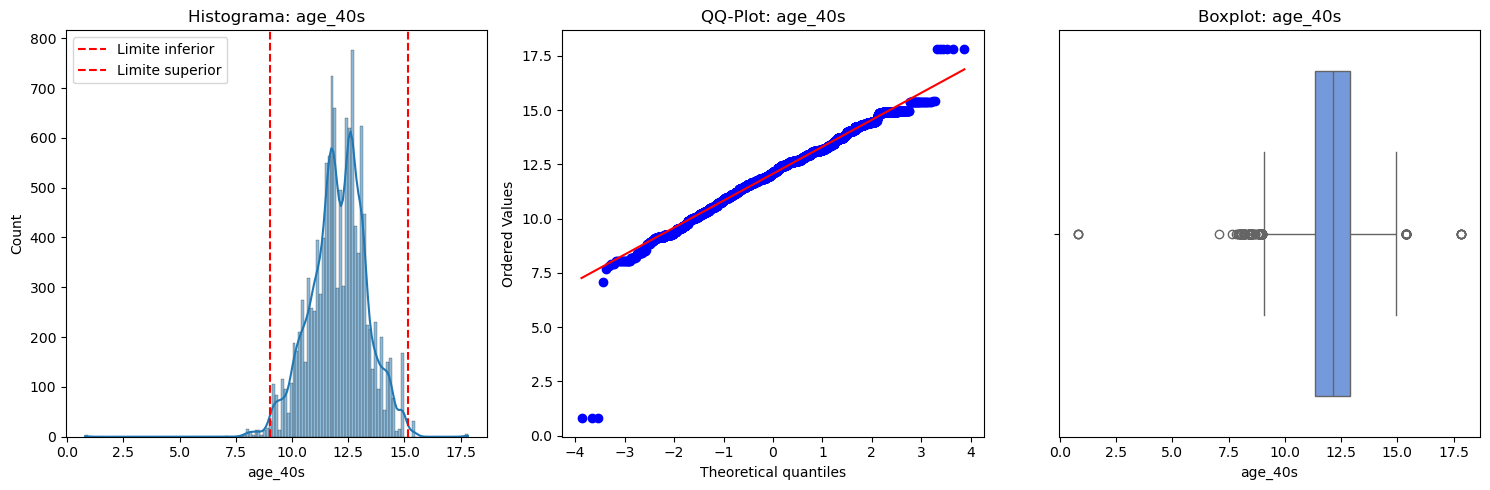

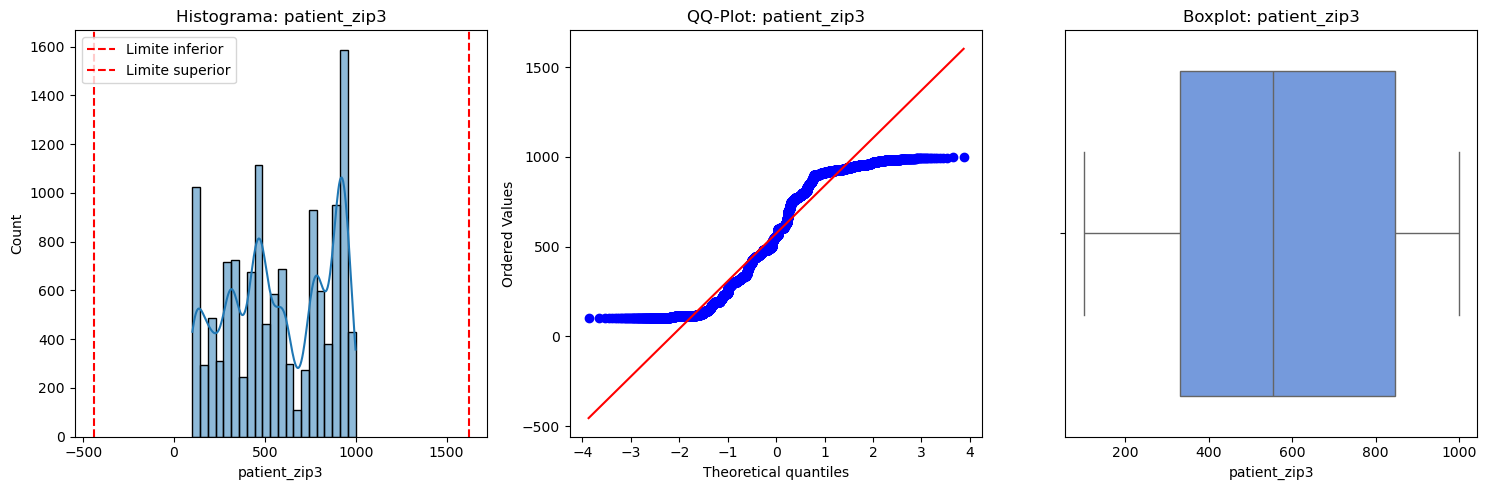

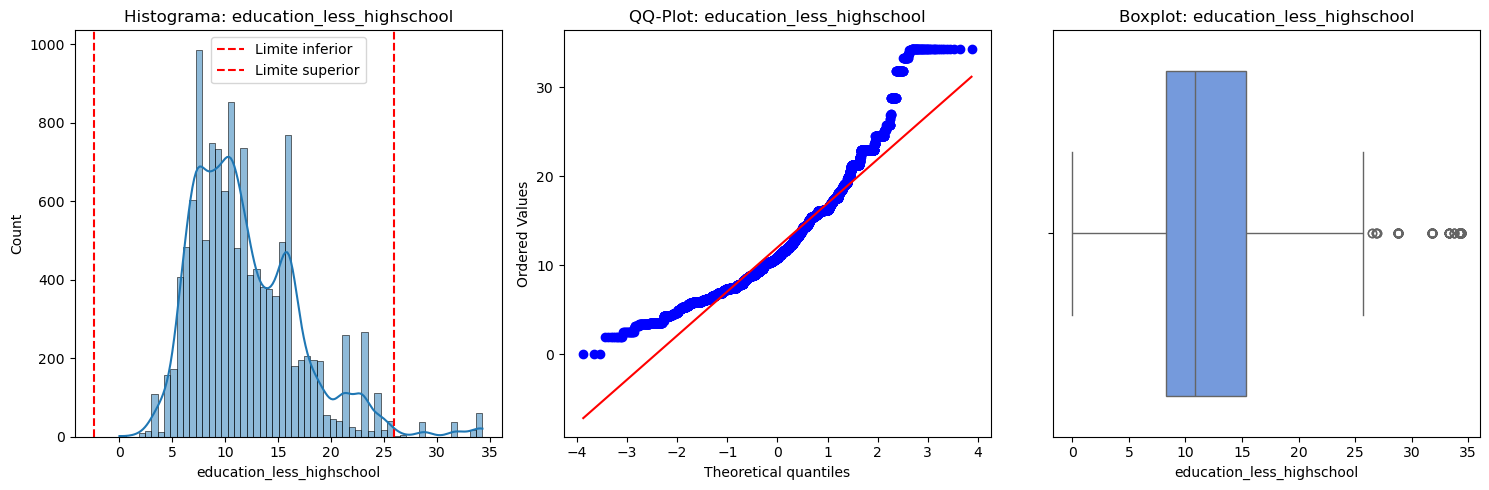

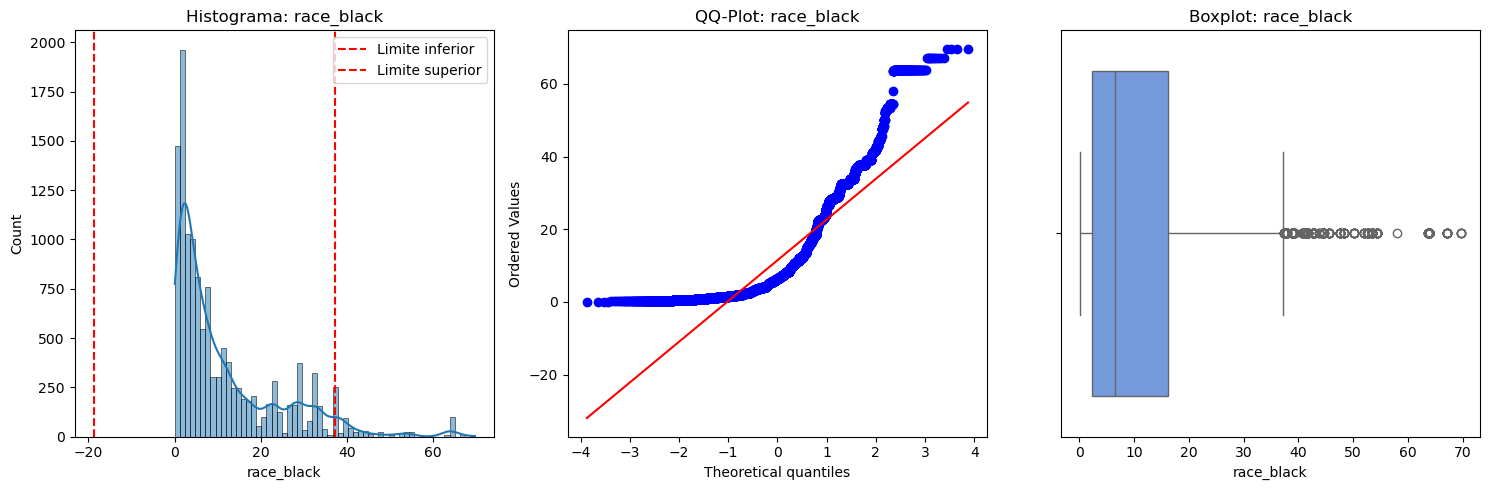

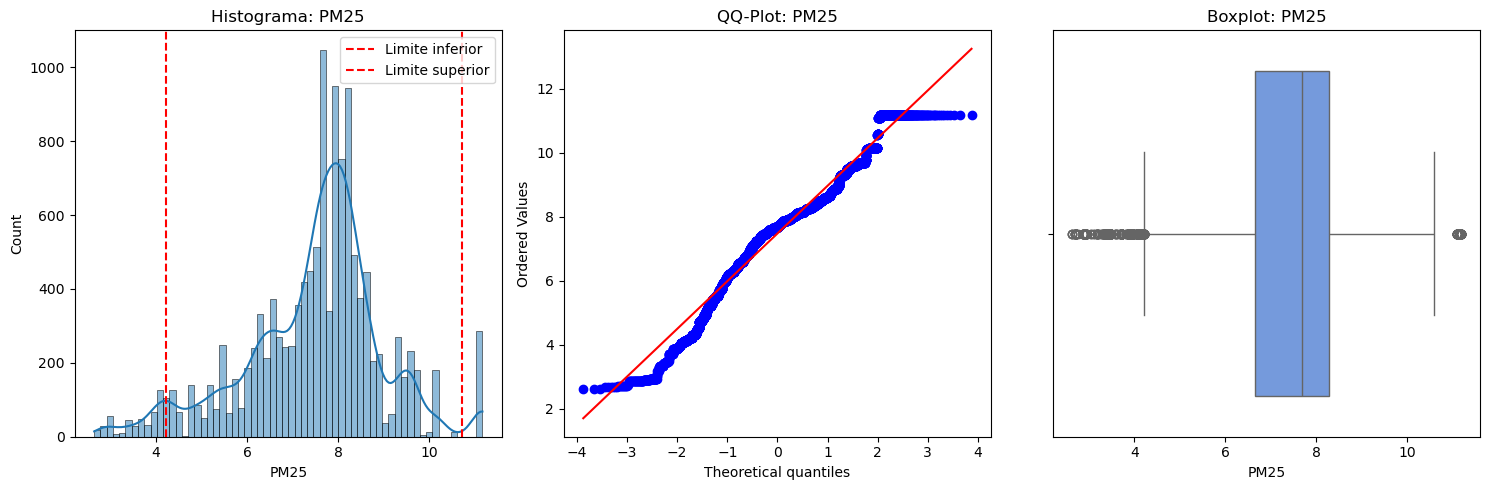

In [34]:
# Deteccion de valores atipicos usando IQR y visualizacion Q-Q plot
numeric_df = df_training.select_dtypes(include='number')
dataframe = numeric_df.copy()

for col in variables_a_analizar:
    # Calculo de cuartiles y rango intercuartil (IQR)
    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    threshold_low = Q1 - 1.5 * IQR
    threshold_high = Q3 + 1.5 * IQR

    plt.figure(figsize=(15, 5))

    # Histograma con limites de outlier
    plt.subplot(1, 3, 1)
    sns.histplot(data=dataframe[col], kde=True)
    plt.axvline(x=threshold_low, color='red', linestyle='--', label='Limite inferior')
    plt.axvline(x=threshold_high, color='red', linestyle='--', label='Limite superior')
    plt.title(f'Histograma: {col}')
    plt.legend()

    # QQ-plot para evaluar normalidad
    plt.subplot(1, 3, 2)
    stats.probplot(dataframe[col].dropna(), dist="norm", plot=plt)
    plt.title(f'QQ-Plot: {col}')

    # Box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(x=dataframe[col], color="cornflowerblue")
    plt.title(f'Boxplot: {col}')

    plt.tight_layout()
    plt.show()

In [35]:
## Ingenieria de Caracteristicas: Segmentacion de Edad
# Transformamos la edad continua en grupos generacionales.

# --- Aplicar a df_training ---
df_training['age_18_29'] = np.where((df_training['patient_age']>=18) & (df_training['patient_age']<30), 1, 0)
df_training['age_30_44'] = np.where((df_training['patient_age']>=30) & (df_training['patient_age']<45), 1, 0)
df_training['age_45_59'] = np.where((df_training['patient_age']>=45) & (df_training['patient_age']<60), 1, 0)
df_training['age_60_74'] = np.where((df_training['patient_age']>=60) & (df_training['patient_age']<75), 1, 0)
df_training['age_75_plus'] = np.where(df_training['patient_age']>=75, 1, 0)

# Eliminar la columna original ya que la informacion esta ahora en los bins
df_training = df_training.drop(columns=['patient_age'])

# --- Aplicar a df_test ---
df_test['age_18_29'] = np.where((df_test['patient_age']>=18) & (df_test['patient_age']<30), 1, 0)
df_test['age_30_44'] = np.where((df_test['patient_age']>=30) & (df_test['patient_age']<45), 1, 0)
df_test['age_45_59'] = np.where((df_test['patient_age']>=45) & (df_test['patient_age']<60), 1, 0)
df_test['age_60_74'] = np.where((df_test['patient_age']>=60) & (df_test['patient_age']<75), 1, 0)
df_test['age_75_plus'] = np.where(df_test['patient_age']>=75, 1, 0)

df_test = df_test.drop(columns=['patient_age'])

print("Ingenieria de Caracteristicas en 'patient_age' completada.")
display(df_training[['age_18_29', 'age_30_44', 'age_45_59', 'age_60_74', 'age_75_plus']].head())

Ingenieria de Caracteristicas en 'patient_age' completada.


,age_18_29,age_30_44,age_45_59,age_60_74,age_75_plus
0,0,0,0,0,1
1,0,0,0,1,0
2,0,1,0,0,0
3,0,0,1,0,0
4,0,0,1,0,0


#### Detección de Varianza Cero y IDs


In [36]:
# Identificamos columnas que no aportan informacion: constantes o identificadores casi unicos.
# Columnas constantes (varianza 0)
cols_constantes = [col for col in df_training.columns if df_training[col].nunique() <= 1]

# Columnas de alta cardinalidad (posibles IDs)
umbral_id = 0.95 * len(df_training)
cols_alta_cardinalidad = [col for col in df_training.columns 
                          if df_training[col].nunique() > umbral_id 
                          and df_training[col].dtype == 'object']

print(f"Columnas constantes (sin informacion): {cols_constantes}")
print(f"Columnas tipo ID (demasiado unicas): {cols_alta_cardinalidad}")

Columnas constantes (sin informacion): ['patient_gender']
Columnas tipo ID (demasiado unicas): []


In [37]:
# Eliminamos columnas redundantes o irrelevantes detectadas
# Ejemplo: genero del paciente (si el dataset es solo femenino o mayoritariamente uno, puede no aportar)
df_training.drop(columns=['patient_gender'], inplace=True)
df_test.drop(columns=['patient_gender'], inplace=True)

#### Correlación con el Target

VARIABLES CON MENOS IMPACTO (POSIBLE RUIDO)
age_30s                      0.019866
age_60_74                    0.019297
income_household_20_to_25    0.018503
education_graduate           0.017951
income_household_5_to_10     0.017389
density                      0.017212
age_18_29                    0.016860
education_stem_degree        0.016693
PM25                         0.016240
age_10_to_19                 0.015174
race_white                   0.014519
race_pacific                 0.014034
education_some_college       0.012293
race_multiple                0.011524
limited_english              0.011250
age_50s                      0.010968
age_over_80                  0.009974
male                         0.009667
female                       0.009664
age_under_10                 0.009066
dtype: float64


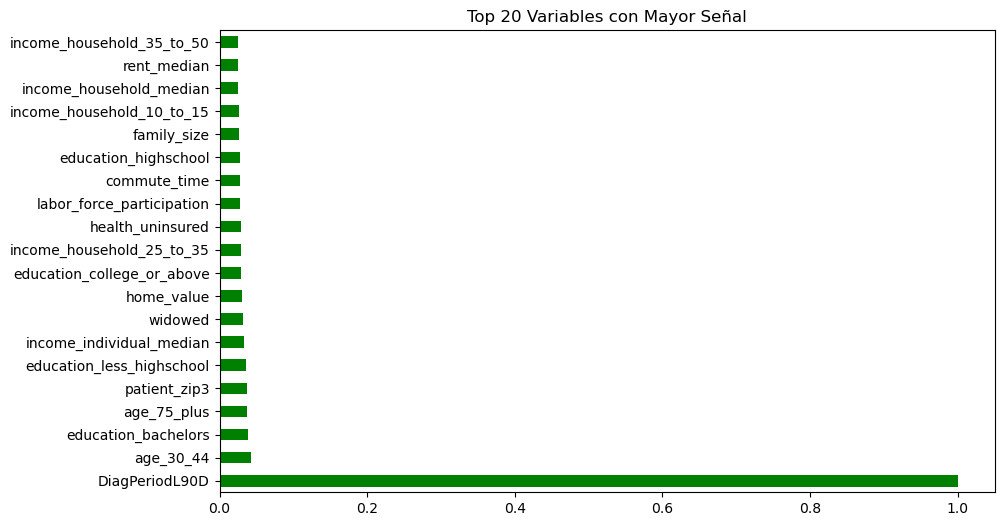

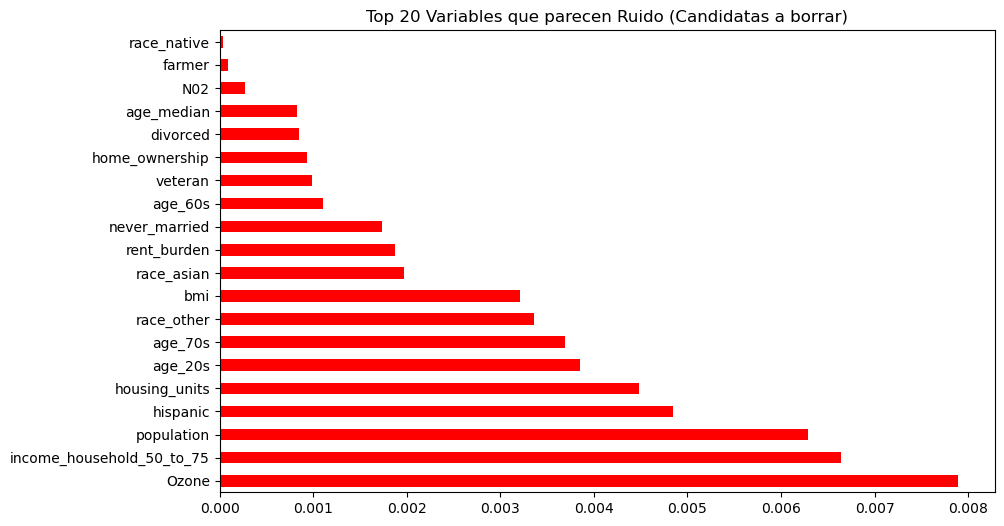

In [38]:
# Analisis de Correlacion: Variable Objetivo vs Variables Numericas
target = 'DiagPeriodL90D'  
nums = df_training.select_dtypes(include=['float64', 'int64'])

# Calculo de correlacion lineal (Pearson)
correlaciones = nums.corrwith(df_training[target]).abs().sort_values(ascending=False)

# Identificacion de variables con correlacion muy baja (posible ruido)
ruido_probable = correlaciones[correlaciones < 0.02]

print("VARIABLES CON MENOS IMPACTO (POSIBLE RUIDO)")
print(ruido_probable.head(20))

# Visualizacion: Las variables mas utiles vs las menos utiles
plt.figure(figsize=(10, 6))
correlaciones.head(20).plot(kind='barh', color='green', label='Mejores')
plt.title("Top 20 Variables con Mayor Señal")
plt.show()

plt.figure(figsize=(10, 6))
ruido_probable.tail(20).plot(kind='barh', color='red', label='Ruido')
plt.title("Top 20 Variables que parecen Ruido (Candidatas a borrar)")
plt.show()

Empty DataFrame
Columns: [Variable, Importancia]
Index: []


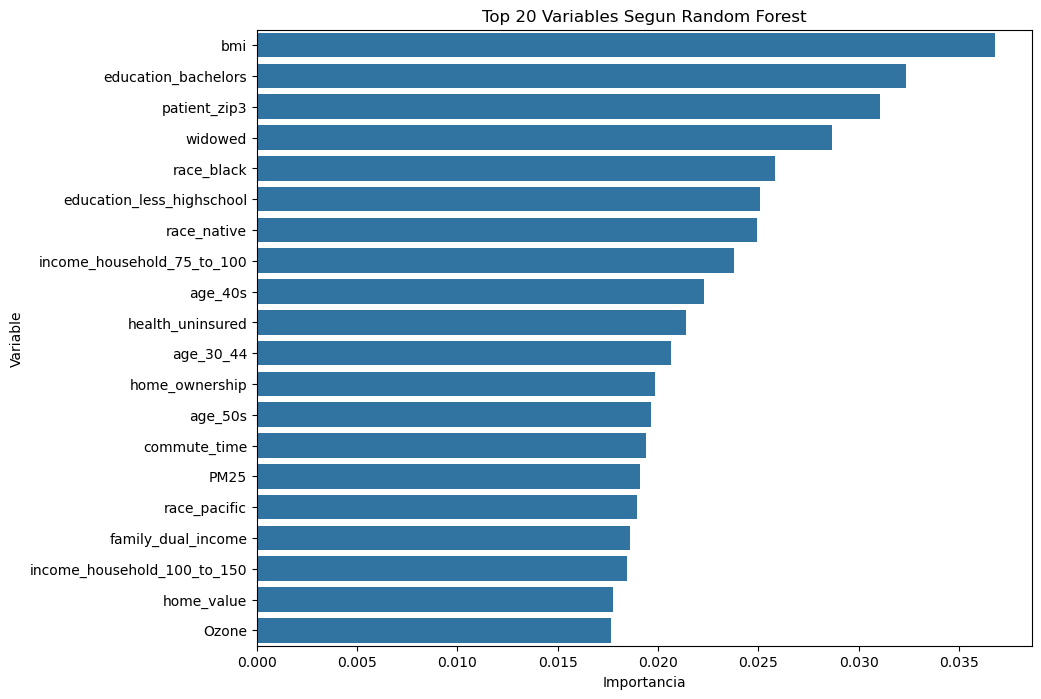

In [39]:
# --- Importancia de Caracteristicas con Random Forest ---
# Usamos un modelo basado en arboles para detectar relaciones no lineales que la correlacion simple no ve.

X_temp = df_training.select_dtypes(include=['number']).drop(columns=[target], errors='ignore')
y_temp = df_training[target]

# Imputacion rapida temporal solo para este chequeo
X_temp = SimpleImputer(strategy='median').fit_transform(X_temp)

# Modelo preliminar para extraer importancia
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf.fit(X_temp, y_temp)

importancia = pd.DataFrame({
    'Variable': df_training.select_dtypes(include=['number']).drop(columns=[target], errors='ignore').columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Variables que el arbol no uso para nada
variables_inutiles = importancia[importancia['Importancia'] < 0.001]
print(variables_inutiles)

plt.figure(figsize=(10, 8))
sns.barplot(data=importancia.head(20), x='Importancia', y='Variable')
plt.title("Top 20 Variables Segun Random Forest")
plt.show()

### Ingeniería de Características Adicional: 

In [40]:
# Agrupacion geografica por region (primeros 3 digitos del ZIP code)
df_training['zip_region'] = df_training['patient_zip3'].astype(str).str[:3]
df_test['zip_region'] = df_test['patient_zip3'].astype(str).str[:3]

print(f"Regiones unicas encontradas: {df_training['zip_region'].nunique()}")

Regiones unicas encontradas: 739


In [41]:
# Creacion de un indice sintetico de contaminacion
# Promediamos varios indicadores ambientales
cols_contaminacion = ['Ozone', 'PM25', 'N02'] 
df_training['indice_contaminacion'] = df_training[cols_contaminacion].mean(axis=1)
df_test['indice_contaminacion'] = df_test[cols_contaminacion].mean(axis=1)

In [42]:
df_test.shape

(5785, 84)

## Codificación de variables categoricas 

In [43]:
# CODIFICACION DE BMI (Mapeo Manual)
# Preservamos el orden ordinal de la variable (Peso normal < Sobrepeso < Obesidad...)
mapa_bmi = {
    'Unknown': -1,
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obesity I': 3,
    'Obesity II': 4,
    'Extreme': 5
}
df_training['bmi_category_enc'] = df_training['bmi_category'].map(mapa_bmi)
df_test['bmi_category_enc'] = df_test['bmi_category'].map(mapa_bmi)

df_training = df_training.drop(columns=['bmi_category'])
df_test = df_test.drop(columns=['bmi_category'])

In [44]:
# FREQUENCY ENCODING para regiones
# Reemplazamos la categoria por su frecuencia de aparicion.

frecuencias = df_training['zip_region'].value_counts()

# Mapeamos al training
df_training['zip_region_freq'] = df_training['zip_region'].map(frecuencias)

# Mapeamos al test. Si hay regiones nuevas en test, se llenan con 0
df_test['zip_region_freq'] = df_test['zip_region'].map(frecuencias).fillna(0)

# Eliminamos columnas originales
df_training = df_training.drop(columns=['zip_region', 'patient_zip3'])
df_test = df_test.drop(columns=['zip_region', 'patient_zip3'])

print(df_training[['zip_region_freq']].head())

   zip_region_freq
0               18
1               96
2               59
3              118
4               31


In [45]:
# ONE-HOT ENCODING
# Para el resto de variables categoricas sin orden.

training_categories = df_training.select_dtypes(include=['object']).columns.tolist() 
print(f"Columnas Categoricas a codificar (One-Hot): {training_categories}")

n_train = len(df_training)

# Concatenamos para asegurar que train y test tengan exactamente las mismas columnas dummy
df_combined = pd.concat([df_training, df_test], ignore_index=True)

# Aplicamos get_dummies
df_combined_encoded = pd.get_dummies(df_combined, columns=training_categories, drop_first=False, dtype=int)

# Separamos de nuevo
df_training_encoded = df_combined_encoded.iloc[:n_train].copy()
df_test_aligned = df_combined_encoded.iloc[n_train:].copy()

# Limpiamos target del test
df_test_aligned = df_test_aligned.drop(columns=['DiagPeriodL90D'])

# Definimos X e y maestras
X_master = df_training_encoded.drop(columns=['DiagPeriodL90D']) 
y_master = df_training_encoded['DiagPeriodL90D'] 

print(f"Columnas en X (entrenamiento): {X_master.shape[1]}")
print(f"Columnas en el set de prueba alineado: {df_test_aligned.shape[1]}")

display(df_test_aligned.head())

Columnas Categoricas a codificar (One-Hot): ['patient_race', 'payer_type', 'patient_state', 'breast_cancer_diagnosis_code', 'metastatic_cancer_diagnosis_code', 'Region', 'Division']
Columnas en X (entrenamiento): 244
Columnas en el set de prueba alineado: 244


,bmi,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,age_50s,...,Region_West,Division_East North Central,Division_East South Central,Division_Middle Atlantic,Division_Mountain,Division_New England,Division_Pacific,Division_South Atlantic,Division_West North Central,Division_West South Central
12870,28.984539,5441.435484,85.620968,40.880328,12.732258,14.088710,10.659677,11.625806,11.208065,15.619355,...,0,1,0,0,0,0,0,0,0,0
12871,28.984539,19613.820510,1555.107692,49.107692,8.069231,8.587179,10.684615,11.302564,10.971795,15.823077,...,0,0,0,0,0,0,0,1,0,0
12872,28.984539,43030.500000,2048.578261,38.852174,11.306522,12.897826,14.121739,13.532609,13.160870,13.378261,...,1,0,0,0,0,0,1,0,0,0
12873,28.984539,43030.500000,2048.578261,38.852174,11.306522,12.897826,14.121739,13.532609,13.160870,13.378261,...,1,0,0,0,0,0,1,0,0,0
12874,23.000000,36054.117650,5294.330882,36.653846,9.761538,11.267692,17.233846,17.441538,13.090769,12.304615,...,1,0,0,0,0,0,1,0,0,0


## Estandarizacion

Aplicamos `StandardScaler` para que las variables numéricas tengan media 0 y desviación estándar 1. Esto es vital para algoritmos sensibles a la escala como PCA, Regresión Logística o KNN.

In [46]:
# Identificar columnas numericas
numeric_cols_encoded = df_training_encoded.select_dtypes(include=[np.number]).columns.tolist()
if 'DiagPeriodL90D' in numeric_cols_encoded:
    numeric_cols_encoded.remove('DiagPeriodL90D')

scaler_normalizacion = StandardScaler()

# Copiamos datos
X_normalizado = X_master.copy()
y_normalizado = y_master.copy()

# Ajustamos scaler en Train y transformamos
X_normalizado[numeric_cols_encoded] = scaler_normalizacion.fit_transform(X_normalizado[numeric_cols_encoded])

# Transformamos Test con el mismo scaler
numeric_cols_test = [col for col in numeric_cols_encoded if col in df_test_aligned.columns]
df_test_aligned[numeric_cols_test] = scaler_normalizacion.transform(df_test_aligned[numeric_cols_test])

# Reconstruimos DataFrame normalizado
df_normalizado = X_normalizado.copy()
df_normalizado['DiagPeriodL90D'] = y_normalizado

print("DataFrame Estandarizado (head):")
display(df_normalizado.head())

DataFrame Estandarizado (head):


,bmi,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,age_50s,...,Division_East North Central,Division_East South Central,Division_Middle Atlantic,Division_Mountain,Division_New England,Division_Pacific,Division_South Atlantic,Division_West North Central,Division_West South Central,DiagPeriodL90D
0,2.254199e-15,0.769954,-0.132173,-2.442077,3.232950,1.349488,1.288903,0.497472,-0.361736,-1.147223,...,-0.547363,-0.20042,-0.36854,-0.286458,-0.019714,1.918776,-0.425128,-0.244326,-0.355220,1.0
1,-1.568928e-01,1.323137,0.240831,-0.570805,0.499922,0.212486,0.280444,0.240760,1.014862,0.376224,...,-0.547363,-0.20042,-0.36854,-0.286458,-0.019714,1.918776,-0.425128,-0.244326,-0.355220,1.0
2,2.888710e+00,0.090288,-0.322092,-0.643439,1.259623,0.788590,-0.225766,0.295374,0.635821,-0.409156,...,-0.547363,-0.20042,-0.36854,-0.286458,-0.019714,-0.521165,-0.425128,-0.244326,2.815156,1.0
3,2.254199e-15,0.867687,0.106070,0.585918,-0.694508,-0.420793,-0.223850,-0.170035,0.467655,0.855150,...,-0.547363,-0.20042,-0.36854,-0.286458,-0.019714,1.918776,-0.425128,-0.244326,-0.355220,0.0
4,2.254199e-15,-0.709555,-0.493815,0.734993,-0.197156,0.535381,-1.131616,-1.074523,0.427615,0.943011,...,-0.547363,-0.20042,-0.36854,3.490913,-0.019714,-0.521165,-0.425128,-0.244326,-0.355220,0.0


#### (Opcional) Normalizacion con MinMax Scaler

Camino alternativo: Escalar datos al rango [0, 1]. Útil si queremos mantener la distribución original sin centrar en cero o para redes neuronales específicas.
*Actualmente comentado para usar StandardScaler.*

In [47]:
# Identificar columnas numericas
# numeric_cols_encoded = df_training_encoded.select_dtypes(include=[np.number]).columns.tolist()
# if 'DiagPeriodL90D' in numeric_cols_encoded:
#     numeric_cols_encoded.remove('DiagPeriodL90D')
#
# # Instanciar MinMaxScaler
# scaler_normalizacion = MinMaxScaler() 
#
# # Copiar X_master y y_master para la normalizacion
# X_normalizado = X_master.copy()
# y_normalizado = y_master.copy()
#
# # Normalizar Train (X_normalizado)
# X_normalizado[numeric_cols_encoded] = scaler_normalizacion.fit_transform(X_normalizado[numeric_cols_encoded])
#
# # Normalizar Test
# numeric_cols_test = [col for col in numeric_cols_encoded if col in df_test_aligned.columns]
# df_test_aligned[numeric_cols_test] = scaler_normalizacion.transform(df_test_aligned[numeric_cols_test])
#
# # Reconstruir df_normalizado
# df_normalizado = X_normalizado.copy()
# df_normalizado['DiagPeriodL90D'] = y_normalizado

### Imputación por Vecinos Cercanos (KNNImputer)

Método avanzado para rellenar valores nulos basándose en la similitud entre filas.
*Actualmente comentado, pero es una estrategia potente para mejorar la calidad de datos.*

In [48]:
# print("Iniciando KNN Imputer")
# knn_imputer = KNNImputer(n_neighbors=5) 
#
# # Separar X e y
# X_normalizado = df_normalizado.drop(columns=['DiagPeriodL90D'])
# y_normalizado = df_normalizado['DiagPeriodL90D']
#
# X_cols = X_normalizado.columns
# X_idx = X_normalizado.index
# test_cols = df_test_aligned.columns
# test_idx = df_test_aligned.index
#
# # Ajustar y transformar en Train
# X_imputado_np = knn_imputer.fit_transform(X_normalizado)
# X_normalizado = pd.DataFrame(X_imputado_np, columns=X_cols, index=X_idx)
#
# # Transformar SOLO en Test
# df_test_imputado_np = knn_imputer.transform(df_test_aligned)
# df_test_aligned = pd.DataFrame(df_test_imputado_np, columns=test_cols, index=test_idx)
#
# # Reconstruir df_normalizado
# df_normalizado = X_normalizado.copy()
# df_normalizado['DiagPeriodL90D'] = y_normalizado.values 

# Selección de Características (RFECV)

**Recursive Feature Elimination with Cross-Validation.**
Este algoritmo elimina iterativamente las características menos importantes y valida el rendimiento del modelo para encontrar el subconjunto óptimo de variables.

In [49]:
# Preparacion de datos para RFE
X_scaled_rfe = df_normalizado.drop(columns=['DiagPeriodL90D'])
y_rfe = df_normalizado['DiagPeriodL90D']
print(f"Dimensiones de X para RFECV: {X_scaled_rfe.shape}")

Dimensiones de X para RFECV: (12870, 244)


In [50]:
# # Ejecucion de RFECV
# # Usamos Regresion Logistica como estimador base por su velocidad y coeficientes interpretables
# estimator_rfe = LogisticRegression(random_state=42, max_iter=6000, solver='liblinear')

# rfecv = RFECV(estimator=estimator_rfe,
#               step=1, # Elimina 1 variable por paso
#               cv=StratifiedKFold(5, random_state=17, shuffle=True),      
#               scoring="roc_auc", 
#               n_jobs=-1, 
#               verbose=1) 

# rfecv.fit(X_scaled_rfe, y_rfe)

# print(" RFECV completado!")
# print(f"Numero optimo de caracteristicas seleccionadas: {rfecv.n_features_}")

# # Filtrado del DataFrame con las mejores caracteristicas
# X_rfe_final = X_scaled_rfe.loc[:, rfecv.support_]

# print("\nDataFrame reducido por RFECV (head):")
# display(X_rfe_final.head())

 #### guardar modelo

In [51]:
# from joblib import dump, load
# dump(rfecv, "rfecv_model.joblib") # Guardar el modelo entrenado
# # rfecv_loaded = load("rfecv_model.joblib")
# # X_rfe_final = X_scaled_rfe.loc[:, rfecv_loaded.support_] # Usar directamente las características seleccionadas


### cargar modelo

In [52]:
rfecv = load("rfecv_model.joblib") # Usar directamente las características seleccionadas
print(f"Número óptimo de características: {rfecv.n_features_}") # Revisar cuántas características seleccionó
X_rfe_final = X_scaled_rfe.loc[:, rfecv.support_] # Aplicar directamente el filtrado de columnas
print("\nDataFrame reducido por RFECV (head):")
display(X_rfe_final.head())

Número óptimo de características: 81

DataFrame reducido por RFECV (head):


,population,density,age_median,age_20s,age_30s,age_40s,age_60s,age_70s,never_married,family_size,...,metastatic_cancer_diagnosis_code_C7901,metastatic_cancer_diagnosis_code_C7919,metastatic_cancer_diagnosis_code_C7931,metastatic_cancer_diagnosis_code_C7951,metastatic_cancer_diagnosis_code_C7960,metastatic_cancer_diagnosis_code_C7962,metastatic_cancer_diagnosis_code_C7971,metastatic_cancer_diagnosis_code_C7972,metastatic_cancer_diagnosis_code_C7981,Region_Midwest
0,0.769954,-0.132173,-2.442077,1.288903,0.497472,-0.361736,-1.963825,-1.701414,1.656186,3.233272,...,-0.012467,-0.008815,-0.149402,-0.407397,-0.035281,-0.008815,-0.008815,-0.008815,-0.193826,-0.627986
1,1.323137,0.240831,-0.570805,0.280444,0.240760,1.014862,-0.923065,-0.793024,0.182025,1.871643,...,-0.012467,-0.008815,-0.149402,-0.407397,-0.035281,-0.008815,-0.008815,-0.008815,-0.193826,-0.627986
2,0.090288,-0.322092,-0.643439,-0.225766,0.295374,0.635821,-0.465023,-0.507460,-0.827389,0.259738,...,-0.012467,-0.008815,-0.149402,-0.407397,-0.035281,-0.008815,-0.008815,-0.008815,-0.193826,-0.627986
3,0.867687,0.106070,0.585918,-0.223850,-0.170035,0.467655,-0.132902,0.261357,-0.335163,-0.464035,...,-0.012467,-0.008815,-0.149402,-0.407397,-0.035281,-0.008815,-0.008815,-0.008815,-0.193826,-0.627986
4,-0.709555,-0.493815,0.734993,-1.131616,-1.074523,0.427615,0.860425,0.841034,-1.505036,0.669264,...,-0.012467,-0.008815,-0.149402,-0.407397,-0.035281,-0.008815,-0.008815,-0.008815,-0.193826,-0.627986


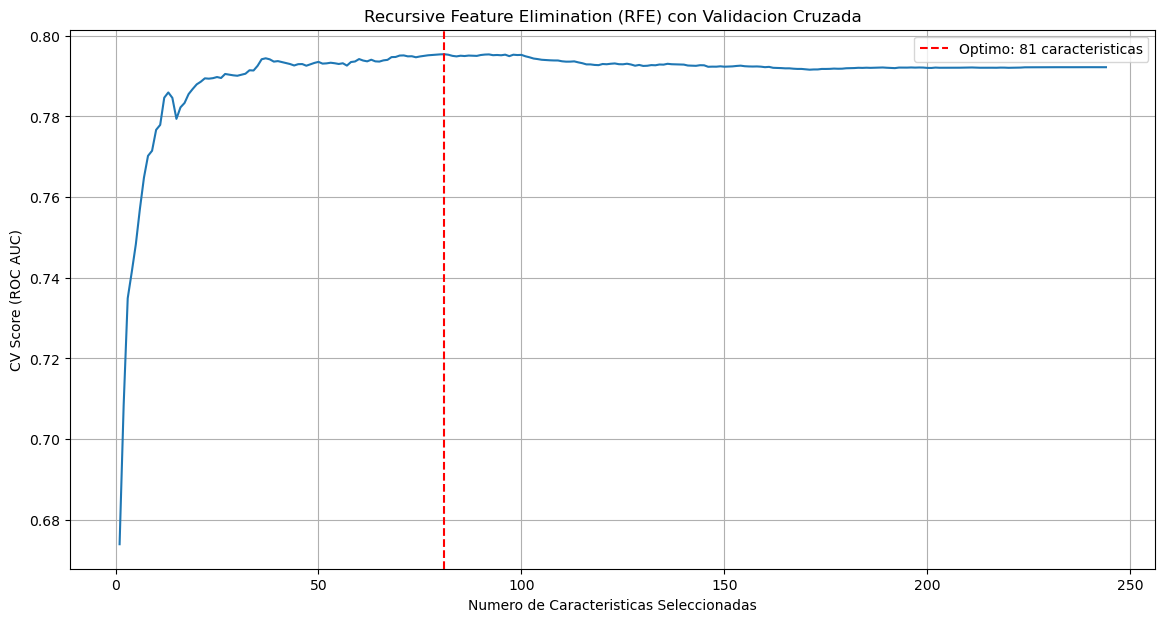

In [53]:
# Grafica de Rendimiento vs Numero de Caracteristicas
cv_scores_rfecv = rfecv.cv_results_['mean_test_score']

plt.figure(figsize=(14, 7))
plt.plot(range(1, len(cv_scores_rfecv) + 1), cv_scores_rfecv)
plt.grid()
plt.xlabel("Numero de Caracteristicas Seleccionadas")
plt.ylabel("CV Score (ROC AUC)")
plt.title("Recursive Feature Elimination (RFE) con Validacion Cruzada")
plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', 
            label=f'Optimo: {rfecv.n_features_} caracteristicas')
plt.legend()
plt.show()

## Análisis de Componentes Principales (PCA):

Técnica de reducción de dimensionalidad no supervisada. Transforma las variables originales en un nuevo conjunto de variables ortogonales (Componentes Principales) que explican la mayor varianza posible.

In [54]:
# 1. Preparacion para PCA
X_scaled = df_normalizado.drop(columns=['DiagPeriodL90D'])
y_pca = df_normalizado['DiagPeriodL90D']
columnas_pca = X_scaled.columns.tolist()

In [55]:
# 2. Ajuste inicial para ver varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)

# 3. Determinacion del numero optimo de componentes (Threshold 95%)
varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

umbral_varianza = 0.95
n_componentes_optimo = np.argmax(varianza_acumulada >= umbral_varianza) + 1

print(f"Se necesitan {n_componentes_optimo} componentes para explicar el {umbral_varianza*100}% de la varianza.")

Se necesitan 158 componentes para explicar el 95.0% de la varianza.


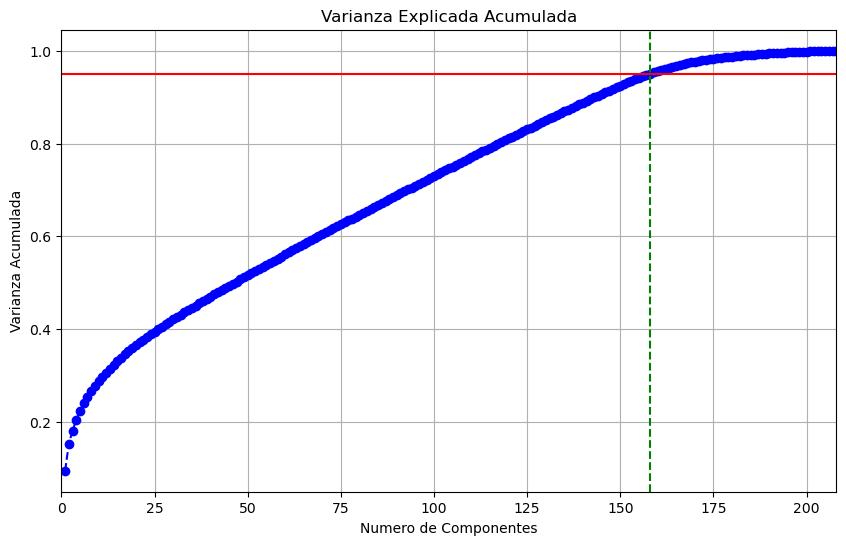

In [56]:
# Grafico Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b')
plt.axhline(y=umbral_varianza, color='r', linestyle='-', label=f'{umbral_varianza*100}% Varianza Objetivo')
plt.axvline(x=n_componentes_optimo, color='g', linestyle='--', label=f'{n_componentes_optimo} Componentes')
plt.title('Varianza Explicada Acumulada')
plt.xlabel('Numero de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.xlim(0, n_componentes_optimo + 50)
plt.show()

In [57]:
# 4. Transformacion final con k componentes optimos
pca_final = PCA(n_components=n_componentes_optimo)
X_pca = pca_final.fit_transform(X_scaled)

print(f"Dimensionalidad reducida: {X_pca.shape[1]} componentes.")

Dimensionalidad reducida: 158 componentes.


In [58]:
# 5. Interpretacion (Cargas factoriales)
# Muestra cuanto contribuye cada variable original a los componentes
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)
loadings_df = pd.DataFrame(loadings, index=columnas_pca, columns=[f"PC{i+1}" for i in range(n_componentes_optimo)])
display(loadings_df.head(10))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC149,PC150,PC151,PC152,PC153,PC154,PC155,PC156,PC157,PC158
bmi,-0.050815,0.040703,-0.027635,-0.016122,0.026180,0.000059,0.024270,-0.000219,0.015295,0.024778,...,-0.019614,-0.038811,-0.013588,-0.062283,0.006591,-0.028379,-0.072782,-0.057618,0.017675,0.006037
population,0.776973,0.379364,-0.052930,0.024780,0.038187,-0.142420,0.063974,-0.164574,0.009424,-0.109379,...,-0.010841,0.001138,0.038062,0.017265,-0.036354,0.038842,-0.016355,0.080259,-0.001111,0.112316
density,0.526032,0.399708,-0.195587,0.349655,-0.024662,-0.243159,0.187013,0.072672,-0.042639,-0.149990,...,-0.018018,0.018559,-0.038621,-0.020733,-0.050101,0.010714,-0.029020,0.092185,0.025186,0.038256
age_median,-0.488373,-0.540399,0.275032,0.537013,0.115268,-0.012109,-0.092537,-0.081100,0.040439,-0.169108,...,-0.013243,-0.003945,-0.020855,-0.011761,0.002079,-0.002559,0.005041,-0.003698,-0.007322,0.007161
age_under_10,0.076486,0.219431,-0.237785,-0.512086,0.170407,-0.437087,0.114491,-0.021096,-0.023052,0.091020,...,0.038326,0.005607,0.039196,0.074683,-0.001090,-0.057659,0.035588,-0.110568,-0.031553,0.147260
age_10_to_19,0.032280,0.114097,-0.161434,-0.457416,0.092436,-0.050555,-0.000041,0.135424,0.011954,0.382912,...,0.007218,-0.009120,0.001613,0.020701,0.051282,0.048623,0.023330,-0.056145,0.077926,-0.117461
age_20s,0.417790,0.515331,-0.161074,-0.310590,-0.303848,0.326371,0.067708,0.124287,-0.089258,0.078675,...,-0.003784,0.007620,0.004361,-0.016117,-0.011160,0.062408,-0.029823,0.111213,0.038990,-0.061344
age_30s,0.641511,0.361394,-0.201377,-0.207074,-0.131242,0.105028,0.071463,-0.009974,-0.047643,-0.112567,...,0.000687,-0.001426,-0.003065,-0.023957,-0.031498,-0.040013,-0.029110,0.047439,-0.049815,0.064841
age_40s,0.498997,-0.122096,-0.075519,-0.069650,0.299977,-0.202868,-0.028580,-0.242956,0.104970,0.074866,...,-0.022868,0.020110,0.023349,-0.013433,-0.053154,-0.104222,0.003818,-0.082679,-0.037658,-0.024771
age_50s,-0.259842,-0.536151,0.034913,0.344707,0.203028,-0.213861,-0.130273,-0.162248,0.080841,0.019371,...,-0.024015,-0.007379,0.037360,-0.010104,-0.003492,-0.099276,-0.000089,-0.100812,-0.042699,-0.033645


### Visualización: Biplot PCA
Observamos la distribución de datos en las dos primeras dimensiones principales y los vectores de las variables originales más influyentes.

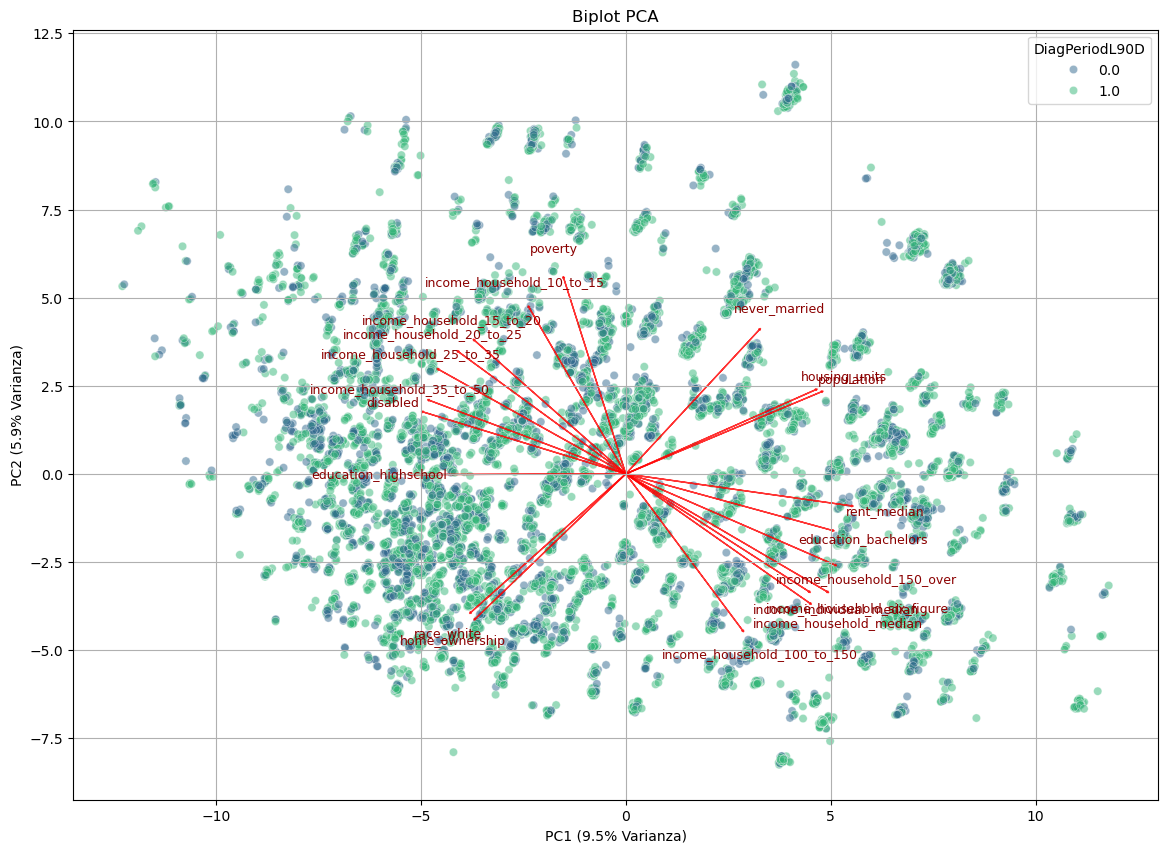

In [59]:
scores = X_pca
var_exp = pca_final.explained_variance_ratio_

plt.figure(figsize=(14, 10))

# Scatter plot de observaciones
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=y_pca, alpha=0.5, palette='viridis')

# Vectores de carga (top 20 variables mas influyentes)
magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
indices_top = np.argsort(magnitudes)[-20:]
arrow_scale = np.max(np.abs(scores[:, :2])) * 0.5 

for i in indices_top:
    x_arrow, y_arrow = loadings[i, 0], loadings[i, 1]
    var_name = columnas_pca[i]
    plt.arrow(0, 0, x_arrow * arrow_scale, y_arrow * arrow_scale,
              head_width=0.05, head_length=0.05, color='red', alpha=0.8)
    plt.text(x_arrow * arrow_scale * 1.15, y_arrow * arrow_scale * 1.15, var_name,
             ha='center', va='center', fontsize=9, color='darkred')

plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}% Varianza)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}% Varianza)")
plt.title("Biplot PCA")
plt.grid(True)
plt.show()

### Preparación de Datasets PCA

In [60]:
# Convertir array de PCA a DataFrame
df_predictores_pca = pd.DataFrame(
  data=X_pca,
  columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# Transformar datos de TEST con el mismo objeto PCA
X_test_produccion_array = pca_final.transform(df_test_aligned)
X_test_produccion_df = pd.DataFrame(
    data=X_test_produccion_array, 
    columns=df_predictores_pca.columns
)

print("Datasets PCA listos para modelado.")

Datasets PCA listos para modelado.


# Modelado con Machine Learning

In [61]:
# Seleccion de estrategia: ¿Usar caracteristicas de RFE o Componentes de PCA?

# --- Opcion A: RFE (Seleccion)
X = X_rfe_final
y = y_rfe 

# --- Opcion B: PCA (Reduccion)
# X = df_predictores_pca
# y = y_pca

print(f"Datos seleccionados. Dimensiones finales de X: {X.shape}")

Datos seleccionados. Dimensiones finales de X: (12870, 81)


In [62]:
# Division Train / Validation (Hold-out)
# Mantenemos estratificacion para preservar la proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.8, 
                                                    stratify=y,
                                                    random_state=10)
print("Train size: {}".format(len(y_train)))
print("Test size: {}".format(len(y_test)))

Train size: 10296
Test size: 2574


### Entrenamiento Multi-Modelo

Probamos una batería de algoritmos para encontrar el que mejor generaliza.

In [63]:
random_state = 13

# Diccionario de modelos a evaluar
clf_keys = [
    "Logistic Regression", 
    "Naive Bayes", 
    "k-Nearest Neighbors",
    "Decision Tree",
    "SGD Classifier",       
    "AdaBoost",             
    "Random Forest",        
    "LightGBM",             
    "MLP (Neural Net)",     
    "XGBoost"               
]

clf_values = [
    LogisticRegression(random_state=random_state, max_iter=15000),
    GaussianNB(),
    KNeighborsClassifier(),
    DecisionTreeClassifier(random_state=random_state, min_samples_split=50,min_samples_leaf=20),
    SGDClassifier(random_state=random_state, loss='log_loss', n_jobs=-1), 
    AdaBoostClassifier(random_state=random_state),
    RandomForestClassifier(random_state=random_state, n_jobs=-1), 
    LGBMClassifier(random_state=random_state, n_jobs=-1, verbosity=-1), 
    MLPClassifier(random_state=random_state, max_iter=1000, early_stopping=True),
    XGBClassifier(random_state=random_state, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
]

clfs = dict(zip(clf_keys, clf_values))

# Bucle de entrenamiento
print("Inicio del entrenamiento de modelos...")
for clf_name, clf in clfs.items():
    clf.fit(X_train, y_train)
    print(f"{clf_name}: Entrenado.")
print("Fin del entrenamiento.\n")

Inicio del entrenamiento de modelos...
Logistic Regression: Entrenado.
Naive Bayes: Entrenado.
k-Nearest Neighbors: Entrenado.
Decision Tree: Entrenado.
SGD Classifier: Entrenado.
AdaBoost: Entrenado.
Random Forest: Entrenado.
LightGBM: Entrenado.
MLP (Neural Net): Entrenado.


d:\Aplicaciones\Anaconda3\envs\mi_env\lib\site-packages\xgboost\training.py:199: UserWarning: [11:31:36] WARNING: D:\bld\xgboost-split_1762060107133\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: Entrenado.
Fin del entrenamiento.



In [64]:
# Evaluacion rapida en set de validacion (Accuracy)
acc = []
for clf_name, clf in clfs.items():
    y_pred = clf.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))

acc_all = pd.DataFrame({"Validation Accuracy": acc}, index=clf_keys)
display(acc_all.sort_values(by="Validation Accuracy", ascending=False))

,Validation Accuracy
Logistic Regression,0.806527
MLP (Neural Net),0.802253
LightGBM,0.800311
SGD Classifier,0.800311
AdaBoost,0.793706
XGBoost,0.791764
Decision Tree,0.786325
Random Forest,0.759518
k-Nearest Neighbors,0.733877
Naive Bayes,0.379953


In [65]:
# Evaluacion Robusta: Validacion Cruzada (Cross-Validation)
scoring = ["accuracy", "roc_auc"]
random_state=10
scores = []

print("Iniciando Validacion Cruzada...")
for clf_name, clf in clfs.items():
    # Omitimos SVC si estuviera presente por lentitud en datasets grandes
    print(f"Validando {clf_name}...")
    score = pd.DataFrame(cross_validate(clf, X, y, cv=StratifiedKFold(3, random_state=random_state, shuffle=True), scoring=scoring)).mean()
    scores.append(score)

cv_scores = pd.concat(scores, axis=1).rename(columns=dict(zip(range(len(clf_keys)), clf_keys)))
print("Validacion Cruzada finalizada.\n")

Iniciando Validacion Cruzada...
Validando Logistic Regression...
Validando Naive Bayes...
Validando k-Nearest Neighbors...
Validando Decision Tree...
Validando SGD Classifier...
Validando AdaBoost...
Validando Random Forest...
Validando LightGBM...
Validando MLP (Neural Net)...
Validando XGBoost...


d:\Aplicaciones\Anaconda3\envs\mi_env\lib\site-packages\xgboost\training.py:199: UserWarning: [11:31:56] WARNING: D:\bld\xgboost-split_1762060107133\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Aplicaciones\Anaconda3\envs\mi_env\lib\site-packages\xgboost\training.py:199: UserWarning: [11:31:56] WARNING: D:\bld\xgboost-split_1762060107133\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Aplicaciones\Anaconda3\envs\mi_env\lib\site-packages\xgboost\training.py:199: UserWarning: [11:31:57] WARNING: D:\bld\xgboost-split_1762060107133\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validacion Cruzada finalizada.



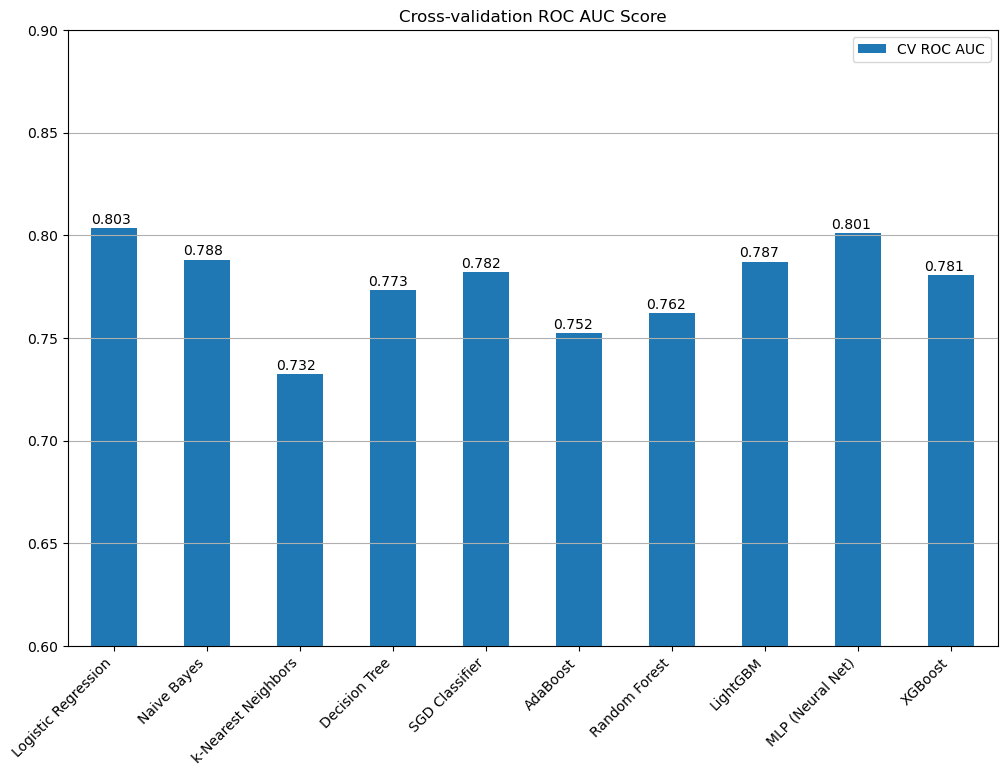

In [66]:
# Visualizacion: ROC AUC Score (Metrica principal para balance de clases)
cv_roc_auc_all = pd.concat([cv_scores.loc["test_roc_auc"].rename("CV ROC AUC")], axis=1)

ax = cv_roc_auc_all.plot.bar(figsize=(12, 8)) 
for p in ax.patches:
    ax.annotate(str(p.get_height().round(3)), (p.get_x()*0.995, p.get_height()*1.003))
plt.xticks(rotation=45, ha='right')
plt.ylim((0.6, 0.9)) 
plt.title("Cross-validation ROC AUC Score")
plt.grid(axis='y')
plt.show()

# Predicción Final


In [67]:
# Seleccion automatica del dataset de prueba correcto
if 'PC1' in X.columns:
    print("--- Usando transformacion PCA para predecir ---")
    X_test_produccion = X_test_produccion_df
else:
    print("--- Usando caracteristicas de RFECV para predecir ---")
    X_test_produccion = df_test_aligned[X.columns]
    
print(f"Dimensiones prediccion: {X_test_produccion.shape}")

--- Usando caracteristicas de RFECV para predecir ---
Dimensiones prediccion: (5785, 81)


In [68]:
# Generacion de predicciones con el modelo seleccionado
# (Modifica 'Logistic Regression' por el modelo ganador del ranking anterior)
modelo_final = 'Logistic Regression' 
print(f"Prediciendo con: {modelo_final}")

predictions = clfs[modelo_final].predict(X_test_produccion)

print("\nEjemplo de predicciones:")
print(predictions[:10])

Prediciendo con: Logistic Regression

Ejemplo de predicciones:
[1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]



Reporte de Clasificacion (Validacion) para: Logistic Regression
              precision    recall  f1-score   support

         0.0       0.89      0.55      0.68       967
         1.0       0.78      0.96      0.86      1607

    accuracy                           0.81      2574
   macro avg       0.84      0.76      0.77      2574
weighted avg       0.82      0.81      0.79      2574



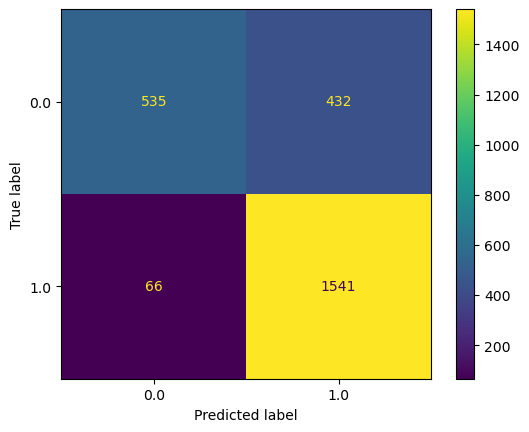

In [69]:
# Evaluacion detallada del modelo seleccionado en validacion
print(f"\nReporte de Clasificacion (Validacion) para: {modelo_final}")
y_pred_validation = clfs[modelo_final].predict(X_test)
print(classification_report(y_test, y_pred_validation))

# Matriz de Confusion
cm = confusion_matrix(y_test, y_pred_validation)    
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clfs[modelo_final].classes_)
disp.plot()
plt.show()

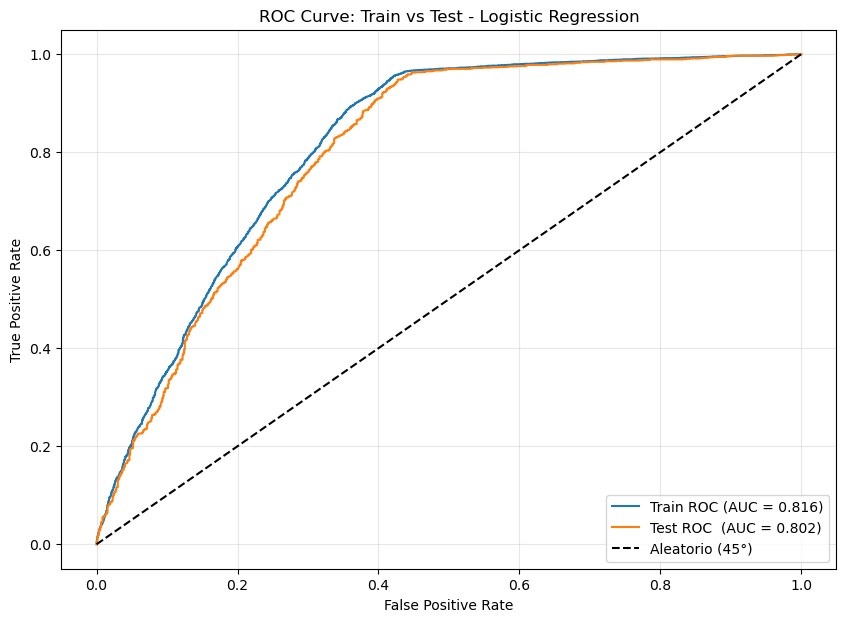

In [70]:
# Mostrar curvas ROC de Train vs Test
y_train_prob = clfs[modelo_final].predict_proba(X_train)[:, 1]
y_test_prob  = clfs[modelo_final].predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)

plt.figure(figsize=(10, 7))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.3f})', color='tab:blue')
plt.plot(fpr_test,  tpr_test,  label=f'Test ROC  (AUC = {auc_test:.3f})',  color='tab:orange')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (45°)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: Train vs Test - {modelo_final}')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


Parece que el modelo no tiene sobreAjuste